# **Basic Stats** - data analysis

In [1]:
# ==== IMPORSTS & PACKAGES ====
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np
from scipy.stats import norm
import re
import calendar

# ==== IMPORT FILES ====
IMPORT_PATH = "../../data/data_analysis_files/"
FILE_FILTERED_GRADES = "df_filtered_final_96pct_grades_excl_2026_20042026.parquet"

# ==== EXPORT SETTINGS ====
# Export images to folder
IMG_EXPORT = True 
IMG_EXPORT_PATH = "../exported_plots/basic_stats/"

EXPORT = True
EXPORT_PATH = None #TBD

# ==== NOTEBOOK SETTINGS ====
#pd.set_option('display.max_columns', None)  # Show all columns
#pd.set_option('display.max_rows', None)  # Show all rows

In [2]:
# ==== FUNCTIONS ====
def load_parquet_to_df(parquet_path, na=False):
    try:
        df = pd.read_parquet(parquet_path)
        print(f"Successfully loaded Parquet from {parquet_path}")
        print(f"DataFrame shape: {df.shape}")
        if na:
            print(f"DataFrame N/A counts:\n{df.isna().sum()}\n")
        print(f"DataFrame columns: {df.columns.tolist()}\n")
        return df
    except Exception as e:
        print(f"Error loading Parquet from {parquet_path}: {e}")
        return None

# ==== LOAD DATAFRAME ====
df_filtered_final = load_parquet_to_df(IMPORT_PATH + FILE_FILTERED_GRADES)

Successfully loaded Parquet from ../../data/data_analysis_files/df_filtered_final_96pct_grades_excl_2026_20042026.parquet
DataFrame shape: (6251, 47)
DataFrame columns: ['Timestamp', 'Author', 'ID', 'Publication Year', 'member_id_ss', 'primary_member_id_s', 'Title', 'MASTER THESIS TITLE', 'BY', 'SUPERVISED BY', 'pdf_file', 'num_tot_pages', 'num_cont_pages', 'num_words_full', 'num_words_cont', 'handin_month', 'num_figures', 'num_tables', 'num_references', 'equation_count', 'pdf_sha256', 'total_sentences', 'total_words', 'unique_words', 'avg_sentence_length', 'avg_word_length', 'lexical_diversity', 'Department_new', 'grading_scientific_contribution', 'grading_methodological_rigor', 'grading_technical_implementation', 'grading_literature_review', 'grading_process_professionalism', 'grading_impact_applicability', 'grading_research_question_alignment', 'grading_total_score', 'grading_meta_attempts', 'grading_meta_original_chars', 'grading_meta_trimmed_at_references', 'grading_meta_input_cha

In [3]:
# ==== EXCLUDING ROWS NO GRADING_TOTAL_SCORE ====
# remove rows with NaN and 0 in grading_total_score
df_filtered_final_noNA = df_filtered_final[(df_filtered_final["grading_total_score"].notnull()) & (df_filtered_final["grading_total_score"] != 0)]

print(f"DataFrame shape is: {df_filtered_final.shape}")
print(f"DataFrame shape after dropping NaN and 0 in grading_total_score: {df_filtered_final_noNA.shape}")
print(df_filtered_final_noNA.columns.tolist())

DataFrame shape is: (6251, 47)
DataFrame shape after dropping NaN and 0 in grading_total_score: (5995, 47)
['Timestamp', 'Author', 'ID', 'Publication Year', 'member_id_ss', 'primary_member_id_s', 'Title', 'MASTER THESIS TITLE', 'BY', 'SUPERVISED BY', 'pdf_file', 'num_tot_pages', 'num_cont_pages', 'num_words_full', 'num_words_cont', 'handin_month', 'num_figures', 'num_tables', 'num_references', 'equation_count', 'pdf_sha256', 'total_sentences', 'total_words', 'unique_words', 'avg_sentence_length', 'avg_word_length', 'lexical_diversity', 'Department_new', 'grading_scientific_contribution', 'grading_methodological_rigor', 'grading_technical_implementation', 'grading_literature_review', 'grading_process_professionalism', 'grading_impact_applicability', 'grading_research_question_alignment', 'grading_total_score', 'grading_meta_attempts', 'grading_meta_original_chars', 'grading_meta_trimmed_at_references', 'grading_meta_input_chars', 'grading_meta_estimated_input_tokens', 'grading_meta_was_

In [4]:
# ==== EXCLUDING ROWS WITH NO VALUE FOR SUB-GRADES ====
sub_grades = [
    'grading_scientific_contribution', 'grading_methodological_rigor',
    'grading_technical_implementation', 'grading_literature_review',
    'grading_process_professionalism', 'grading_impact_applicability',
    'grading_research_question_alignment'
 ]
df_filtered_final_noNA_subgrades = df_filtered_final_noNA.copy()

# Keep only rows where all sub-grades are present and non-zero.
mask_complete = df_filtered_final_noNA_subgrades[sub_grades].notna().all(axis=1)
mask_non_zero = (df_filtered_final_noNA_subgrades[sub_grades] != 0).all(axis=1)
df_filtered_final_noNA_subgrades = df_filtered_final_noNA_subgrades[mask_complete & mask_non_zero]

print(f"DataFrame shape after dropping rows with NaN/0 in sub-grades: {df_filtered_final_noNA_subgrades.shape}")

DataFrame shape after dropping rows with NaN/0 in sub-grades: (5994, 47)


# General stats

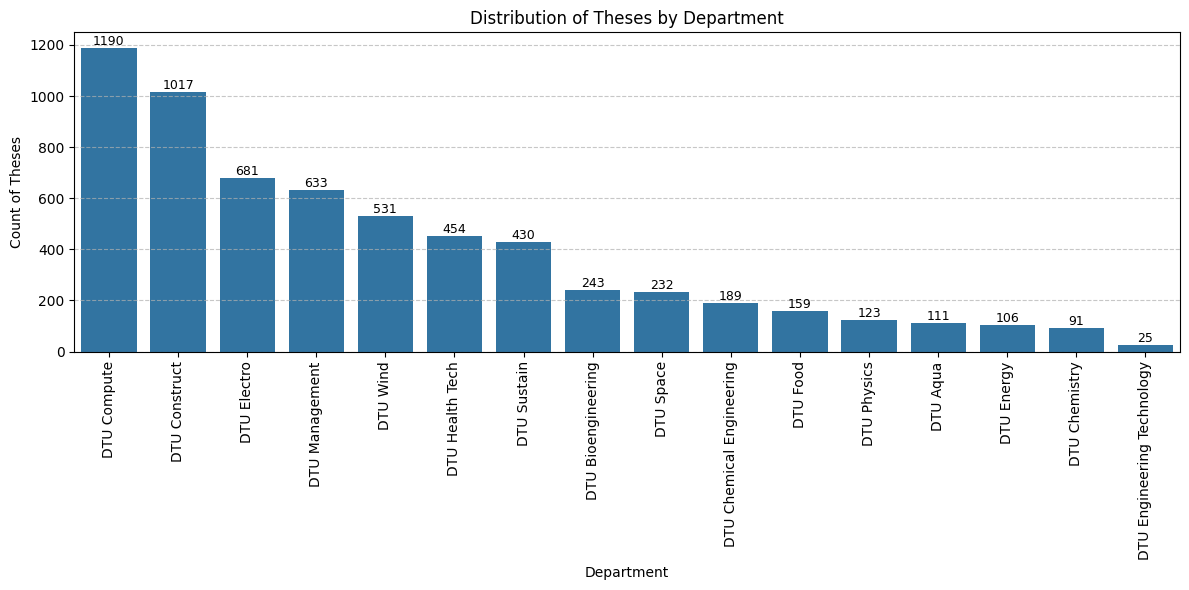

In [5]:
# print table of df department_new count of each unique
dept_counts = df_filtered_final['Department_new'].value_counts()
#print("--- Thesis Count by Department ---")
#print(dept_counts)

# plot df department_new count of each unique + show count on bars
plt.figure(figsize=(12, 6))
ax = sns.countplot(
    data=df_filtered_final,
    x='Department_new',
    order=df_filtered_final['Department_new'].value_counts().index
)

# add count labels at the end (top) of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=0, fontsize=9)

plt.xticks(rotation=90)
plt.title('Distribution of Theses by Department')
plt.xlabel('Department')
plt.ylabel('Count of Theses')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
if IMG_EXPORT:
    plt.savefig(IMG_EXPORT_PATH + 'department_distribution.png')
plt.show()

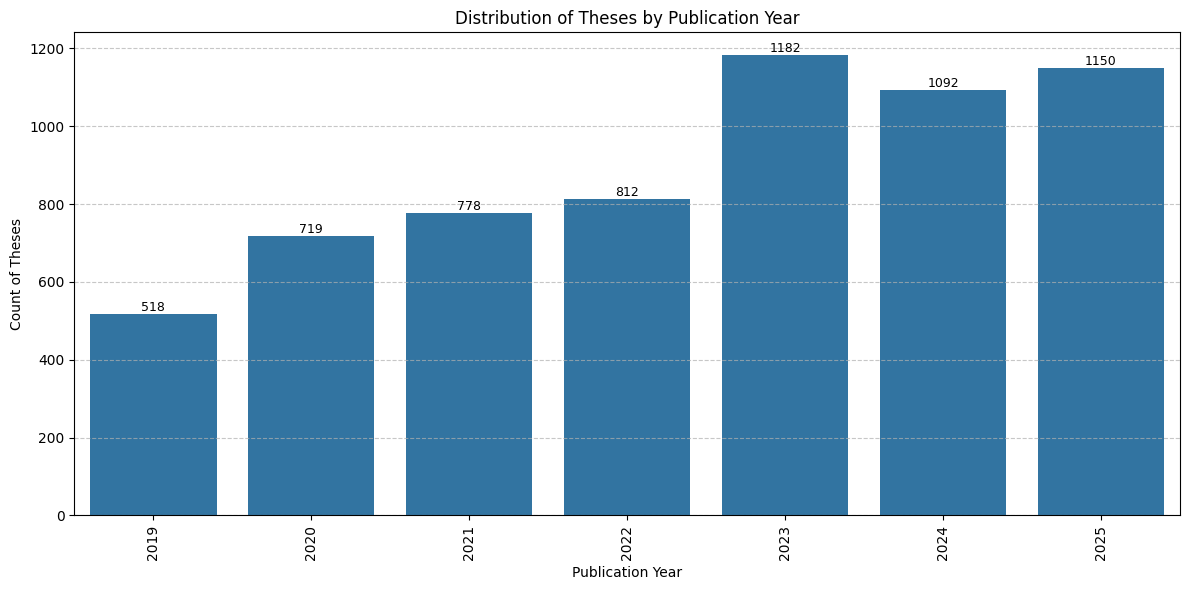

In [6]:
# plot df "Publication Year" count of each unique + show count on bars
plt.figure(figsize=(12, 6))

year_order = sorted(pd.to_numeric(df_filtered_final["Publication Year"], errors="coerce").dropna().unique())

ax = sns.countplot(
    data=df_filtered_final,
    x='Publication Year',
    order=year_order
)

# add count labels at the end (top) of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=0, fontsize=9)

plt.xticks(rotation=90)
plt.title('Distribution of Theses by Publication Year')
plt.xlabel('Publication Year')
plt.ylabel('Count of Theses')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
if IMG_EXPORT:
    plt.savefig(IMG_EXPORT_PATH + 'publication_year_distribution.png')
plt.show()

## Dataset overview and basic statistics

The dataset consists of $5,994$ thesis from 2019 to 2025 and 47 variables covering thesis metadata, structural document features, and grading outcomes. A list of all variables in the dataset are available in .... It ranges from 2019 to 2025 as seen in .... The sample is distributed across 16 DTU departments, with the largest shares coming from DTU Compute, DTU Construct, DTU Electro and DTU Management. The median thesis spans $66$ content pages and $19,132$ words, with a median lexical diversity of $0.143$. Grades are concentrated at the upper end of the scale: the total score has a mean of $79.25$ and a median of $80$.

In [7]:
from IPython.display import display

raw_df = df_filtered_final.copy()

structural_cols = [
    'num_tot_pages',
    'num_cont_pages',
    'num_words_full',
    'num_words_cont',
    'num_figures',
    'num_tables',
    'num_references',
    'equation_count',
    'total_sentences',
    'total_words',
    'unique_words',
    'avg_sentence_length',
    'avg_word_length',
    'lexical_diversity',
]

grade_cols = [
    'grading_scientific_contribution',
    'grading_methodological_rigor',
    'grading_technical_implementation',
    'grading_literature_review',
    'grading_process_professionalism',
    'grading_impact_applicability',
    'grading_research_question_alignment',
    'grading_total_score',
]

complete_total_mask = raw_df['grading_total_score'].notna() & (raw_df['grading_total_score'] != 0)
complete_subgrade_mask = complete_total_mask & raw_df[grade_cols[:-1]].notna().all(axis=1) & (raw_df[grade_cols[:-1]] != 0).all(axis=1)
core_complete_mask = raw_df[['Publication Year', 'Department_new'] + structural_cols + grade_cols].notna().all(axis=1)

quality_summary = pd.DataFrame([
    {'metric': 'Rows in raw dataset', 'value': len(raw_df)},
    {'metric': 'Columns in raw dataset', 'value': raw_df.shape[1]},
    {'metric': 'Unique thesis hashes (pdf_sha256)', 'value': raw_df['pdf_sha256'].nunique(dropna=True)},
    {'metric': 'Unique thesis filenames (pdf_file)', 'value': raw_df['pdf_file'].nunique(dropna=True)},
    {'metric': 'Exact duplicate rows', 'value': raw_df.duplicated().sum()},
    {'metric': 'Publication year span', 'value': f"{int(raw_df['Publication Year'].min())} to {int(raw_df['Publication Year'].max())}"},
    {'metric': 'Rows with non-missing and non-zero total grade', 'value': int(complete_total_mask.sum())},
    {'metric': 'Rows with all sub-grades present and non-zero', 'value': int(complete_subgrade_mask.sum())},
    {'metric': 'Rows complete on core analysis variables', 'value': int(core_complete_mask.sum())},
])

missing_summary = (
    raw_df[structural_cols + grade_cols + ['handin_month', 'handin_month_num', 'Department_new', 'SUPERVISED BY']]
    .isna()
    .sum()
    .rename('missing_count')
    .to_frame()
)
missing_summary['missing_pct'] = (missing_summary['missing_count'] / len(raw_df) * 100).round(2)
missing_summary = missing_summary.sort_values(['missing_count', 'missing_pct'], ascending=False)

department_summary = (
    raw_df['Department_new']
    .value_counts(dropna=False)
    .rename_axis('Department')
    .reset_index(name='count')
)
department_summary['share_pct'] = (department_summary['count'] / len(raw_df) * 100).round(2)

year_summary = (
    raw_df['Publication Year']
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis('Publication Year')
    .reset_index(name='count')
)
year_summary['share_pct'] = (year_summary['count'] / len(raw_df) * 100).round(2)

display(quality_summary)
display(missing_summary.head(20))
display(department_summary.head(10))
display(year_summary)

print('Analytical sample used for the grading-focused analyses:')
print(f"- {int(complete_total_mask.sum()):,} rows with a valid total grade")
print(f"- {int(complete_subgrade_mask.sum()):,} rows with all sub-grade metrics present and non-zero")
print(f"- {int(core_complete_mask.sum()):,} rows complete on the core analysis variables")

,metric,value
0,Rows in raw dataset,6251
1,Columns in raw dataset,47
2,Unique thesis hashes (pdf_sha256),4249
3,Unique thesis filenames (pdf_file),4254
4,Exact duplicate rows,1976
5,Publication year span,2019 to 2025
6,Rows with non-missing and non-zero total grade,5995
7,Rows with all sub-grades present and non-zero,5994
8,Rows complete on core analysis variables,5994


,missing_count,missing_pct
grading_scientific_contribution,233,3.73
grading_methodological_rigor,233,3.73
grading_technical_implementation,233,3.73
grading_literature_review,233,3.73
grading_process_professionalism,233,3.73
grading_impact_applicability,233,3.73
grading_research_question_alignment,233,3.73
grading_total_score,233,3.73
handin_month,202,3.23
handin_month_num,202,3.23


,Department,count,share_pct
0,DTU Compute,1190,19.04
1,DTU Construct,1017,16.27
2,DTU Electro,681,10.89
3,DTU Management,633,10.13
4,DTU Wind,531,8.49
5,DTU Health Tech,454,7.26
6,DTU Sustain,430,6.88
7,DTU Bioengineering,243,3.89
8,DTU Space,232,3.71
9,DTU Chemical Engineering,189,3.02


,Publication Year,count,share_pct
0,2019,518,8.29
1,2020,719,11.50
2,2021,778,12.45
3,2022,812,12.99
4,2023,1182,18.91
5,2024,1092,17.47
6,2025,1150,18.40


Analytical sample used for the grading-focused analyses:
- 5,995 rows with a valid total grade
- 5,994 rows with all sub-grade metrics present and non-zero
- 5,994 rows complete on the core analysis variables


In [8]:
analysis_df = raw_df.loc[complete_subgrade_mask].copy()

paper_vars = [
    'num_tot_pages',
    'num_cont_pages',
    'num_words_full',
    'num_words_cont',
    'num_figures',
    'num_tables',
    'num_references',
    'equation_count',
    'total_sentences',
    'total_words',
    'unique_words',
    'avg_sentence_length',
    'avg_word_length',
    'lexical_diversity',
    'grading_scientific_contribution',
    'grading_methodological_rigor',
    'grading_technical_implementation',
    'grading_literature_review',
    'grading_process_professionalism',
    'grading_impact_applicability',
    'grading_research_question_alignment',
    'grading_total_score',
]

paper_summary = analysis_df[paper_vars].describe(percentiles=[0.25, 0.5, 0.75]).T
paper_summary['iqr'] = paper_summary['75%'] - paper_summary['25%']
paper_summary = paper_summary[['count', 'mean', 'std', '25%', '50%', '75%', 'iqr', 'min', 'max']].round(2)

display(paper_summary)

paper_text = (
    f"The analytical sample comprises {len(analysis_df):,} thesis records from {analysis_df['Publication Year'].min():.0f} to {analysis_df['Publication Year'].max():.0f}. "
    f"The median thesis spans {analysis_df['num_cont_pages'].median():.0f} content pages and {analysis_df['total_words'].median():.0f} words, "
    f"with a median lexical diversity of {analysis_df['lexical_diversity'].median():.3f}. "
    f"Grades are concentrated at the upper end of the scale: the total score has a mean of {analysis_df['grading_total_score'].mean():.2f} and a median of {analysis_df['grading_total_score'].median():.0f}."
)
print(paper_text)

,count,mean,std,25%,50%,75%,iqr,min,max
num_tot_pages,5994.0,90.88,42.22,65.00,83.00,107.00,42.00,1.00,531.00
num_cont_pages,5994.0,69.98,28.27,52.00,66.00,83.00,31.00,1.00,436.00
num_words_full,5994.0,26372.90,13701.55,17643.50,23534.00,31983.00,14339.50,16.00,192386.00
num_words_cont,5994.0,21863.75,10329.45,15137.00,20255.00,26593.25,11456.25,16.00,180529.00
num_figures,5994.0,46.39,34.26,24.00,39.00,60.00,36.00,0.00,455.00
num_tables,5994.0,11.43,12.44,4.00,8.00,16.00,12.00,0.00,170.00
num_references,5994.0,47.14,33.23,24.00,41.00,62.00,38.00,0.00,288.00
equation_count,5985.0,52.22,64.69,11.00,30.00,68.00,57.00,0.00,638.00
total_sentences,5994.0,997.08,393.48,701.00,944.00,1251.00,550.00,1.00,3011.00
total_words,5994.0,19809.59,7194.92,14316.50,19132.50,25185.00,10868.50,16.00,40357.00


The analytical sample comprises 5,994 thesis records from 2019 to 2025. The median thesis spans 66 content pages and 19132 words, with a median lexical diversity of 0.143. Grades are concentrated at the upper end of the scale: the total score has a mean of 79.25 and a median of 80.


## Trends related to grading

In [9]:
# 1. Load the data
# Choosing the file where NaN and 0 values in grading_total_score have been removed for accurate analysis
df = df_filtered_final_noNA_subgrades.copy()

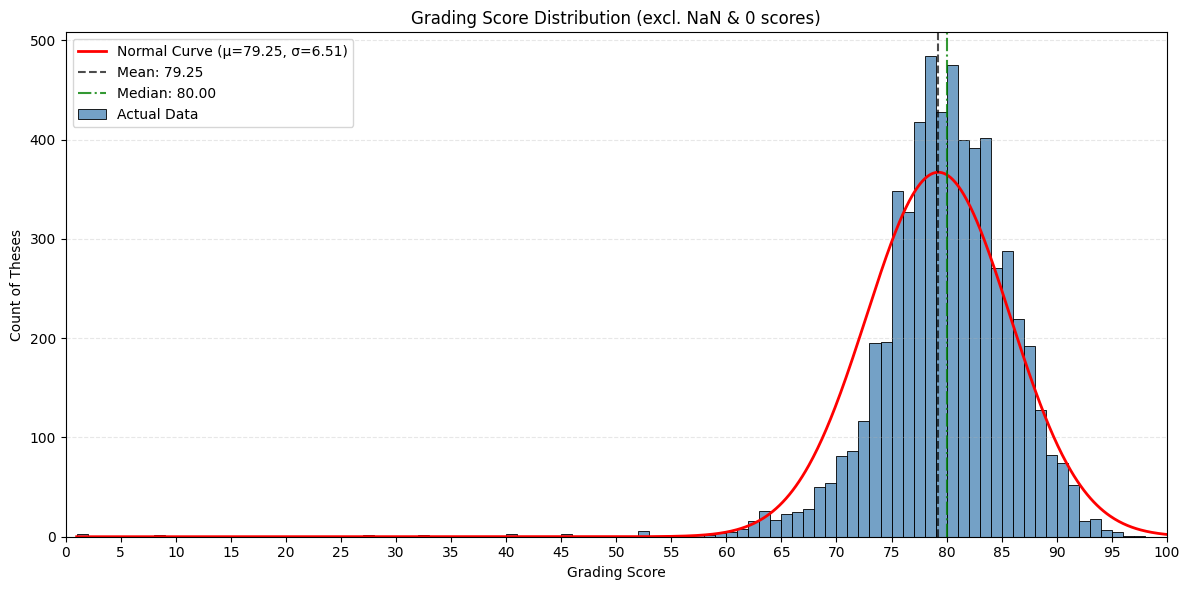

In [10]:
show_count = False

# 1. Prepare data
scores = pd.to_numeric(df["grading_total_score"], errors="coerce").dropna()

# 2. Calculate parameters
mu, std = scores.mean(), scores.std()
median_score = scores.median()

# 3. Plotting
plt.figure(figsize=(12, 6))

# Histogram - Ensuring bins cover the 1-100 range precisely
bin_range = np.arange(1, 102) 
ax = sns.histplot(scores, bins=bin_range, color="steelblue", kde=False, label="Actual Data")

# 4. Overlay the Normal Distribution (Red Line)
# Even if the data is skewed, this shows HOW much it deviates from a "perfect" bell curve
x = np.linspace(1, 100, 1000)
# Scale the PDF: (PDF value) * (Total Number of Samples) * (Bin Width)
p = norm.pdf(x, mu, std) * len(scores) * 1 

plt.plot(x, p, 'r', linewidth=2, label=f'Normal Curve (μ={mu:.2f}, σ={std:.2f})')

# 5. Add vertical lines for central tendency to visualize skew
plt.axvline(mu, color='k', linestyle='--', alpha=0.7, label=f'Mean: {mu:.2f}')
plt.axvline(median_score, color='green', linestyle='-.', alpha=0.8, label=f'Median: {median_score:.2f}')

if show_count == True:
    # Label bars (optional: might get crowded if 100 bars are all filled)
    for container in ax.containers:
        # Only label bars with a count > 0 to keep it clean
        ax.bar_label(container, fmt='%d', padding=2, fontsize=8)

# Formatting
plt.xlim(1, 100)
plt.xticks(np.arange(0, 101, 5))
plt.title("Grading Score Distribution (excl. NaN & 0 scores)")
plt.xlabel("Grading Score")
plt.ylabel("Count of Theses")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
if IMG_EXPORT:
    plt.savefig(IMG_EXPORT_PATH + 'grading_score_distribution.png')
plt.show()

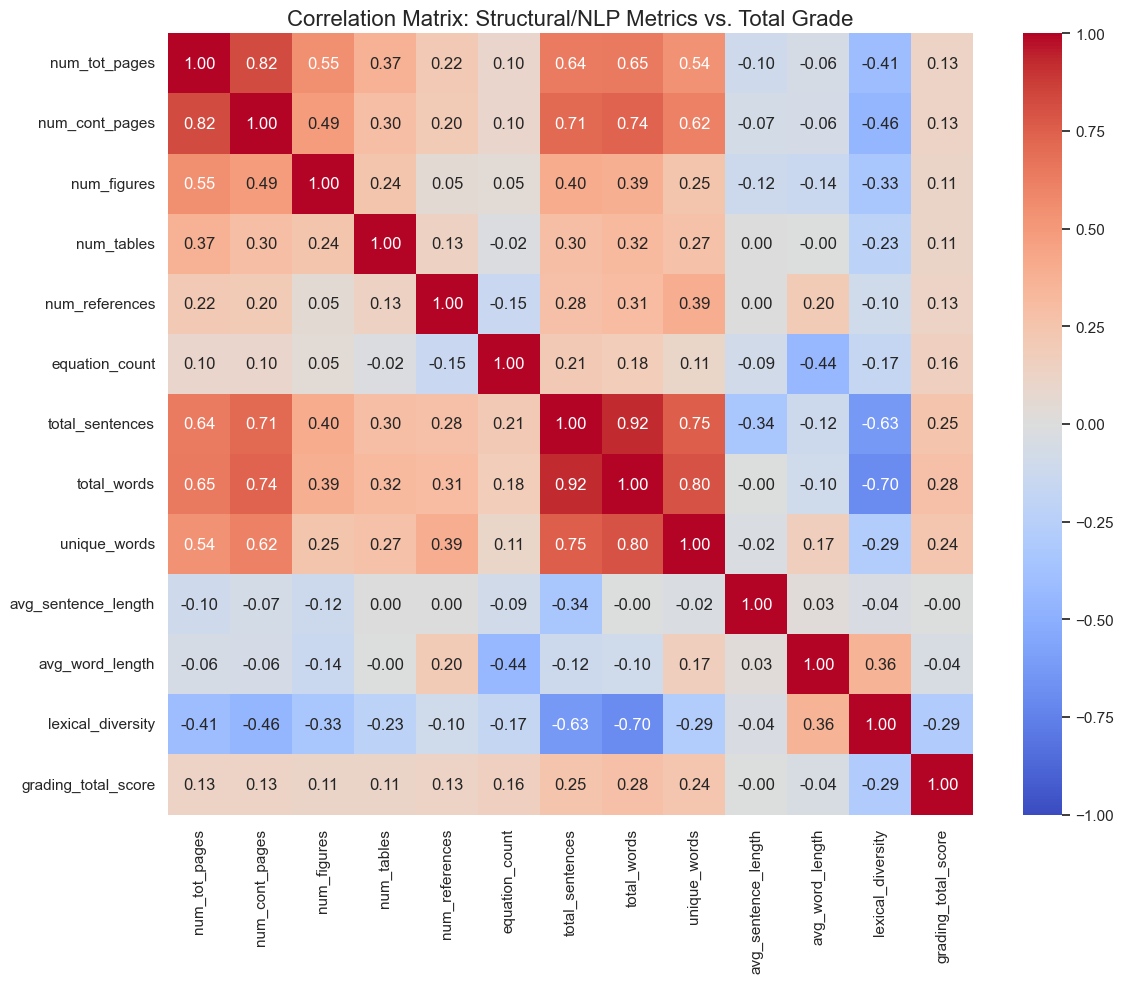

/var/folders/kb/z559lc5s7jzbc1c4j024j2w40000gn/T/ipykernel_80982/1776660738.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Publication Year', y=target, palette='magma')


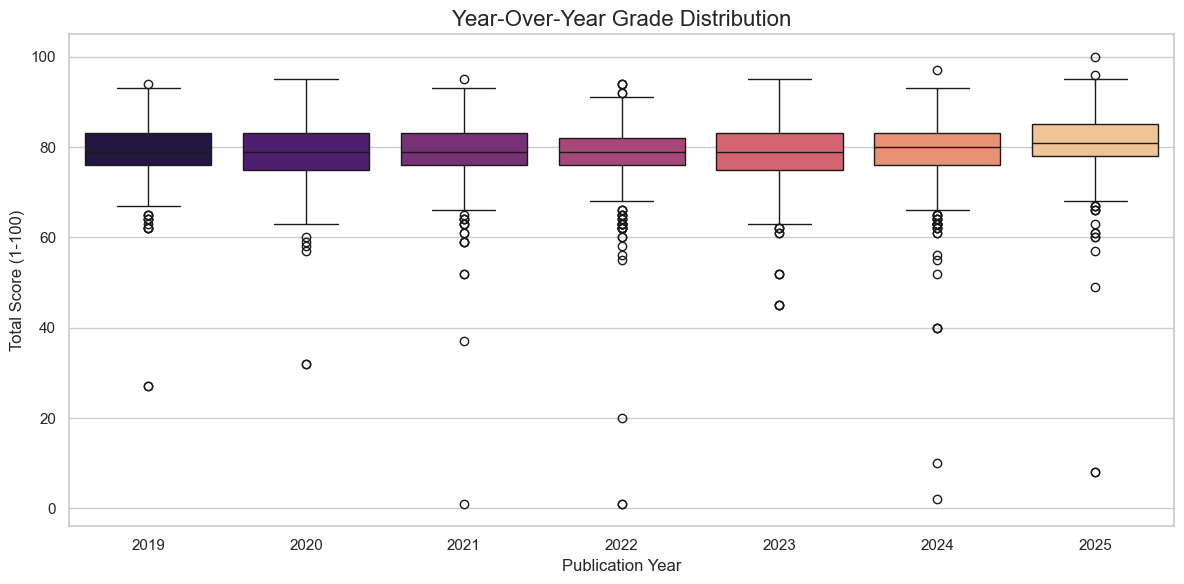

/var/folders/kb/z559lc5s7jzbc1c4j024j2w40000gn/T/ipykernel_80982/1776660738.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Department_new', y=target, order=order, palette='viridis')


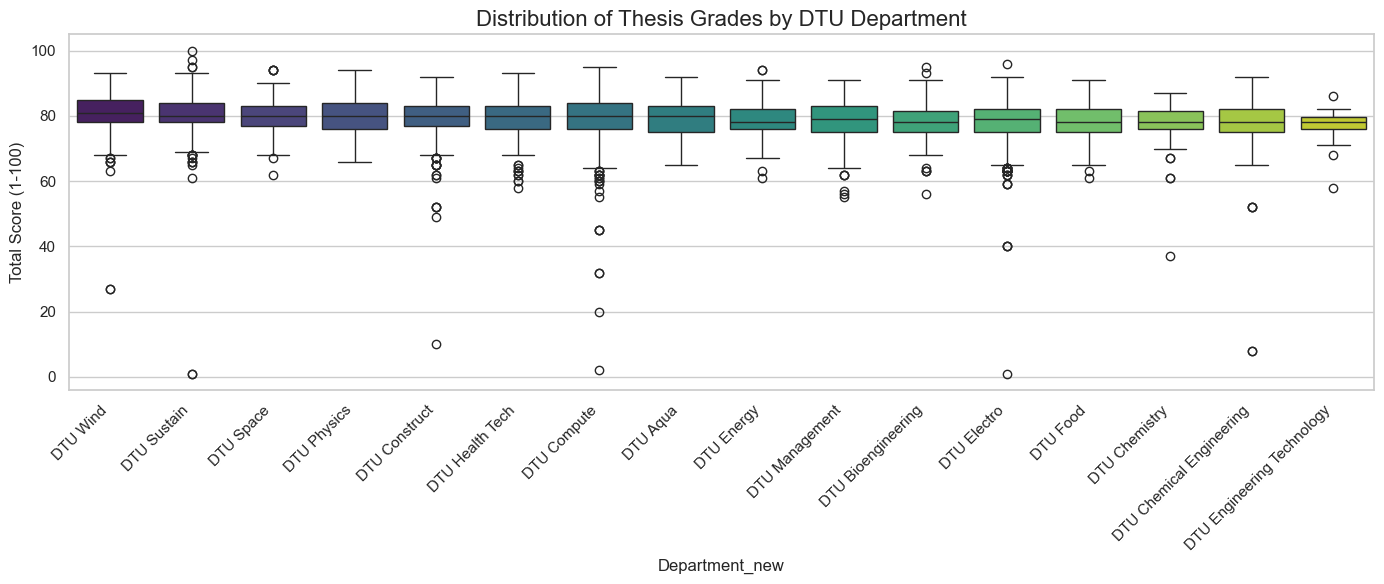

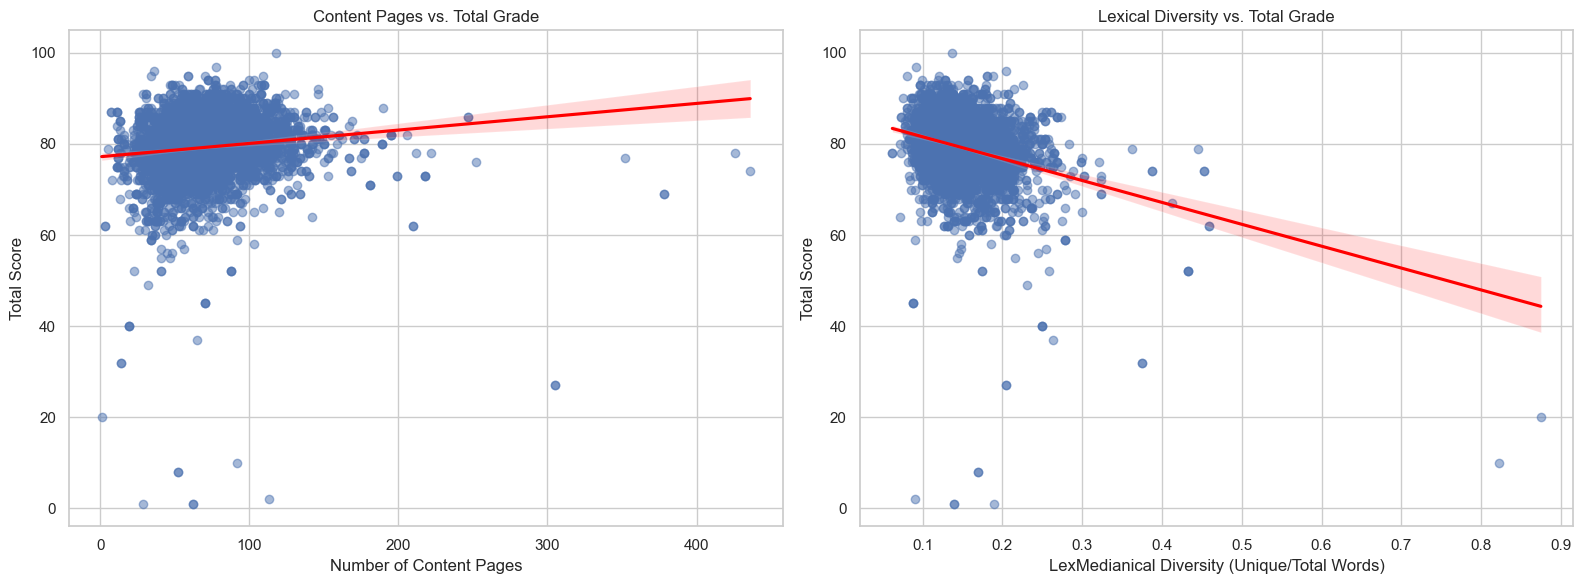

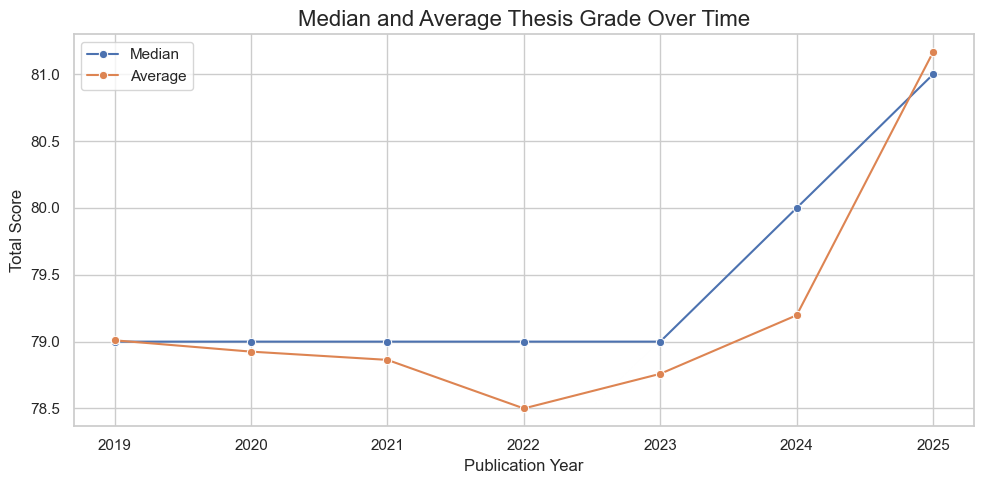

In [11]:
# 2. Clean the handin_month column (as you noted: disregard the year)
# Assuming the format is something like "May-2023" or "2023-05", we extract just the month text or number.
# If it's a string like "May 2023", we can do:
df['handin_month_clean'] = df['handin_month'].astype(str).str.replace(r'\d+', '', regex=True).str.strip()

# 3. Define the feature categories
nlp_structural_features = [
    'num_tot_pages', 'num_cont_pages', 'num_figures', 'num_tables', 
    'num_references', 'equation_count', 'total_sentences', 'total_words', 
    'unique_words', 'avg_sentence_length', 'avg_word_length', 'lexical_diversity'
]

sub_grades = [
    'grading_scientific_contribution', 'grading_methodological_rigor',
    'grading_technical_implementation', 'grading_literature_review',
    'grading_process_professionalism', 'grading_impact_applicability',
    'grading_research_question_alignment'
]

target = 'grading_total_score'

# Set visual style
sns.set_theme(style="whitegrid")

# ==========================================
# PLOT 1: Correlation Heatmap (NLP & Structural)
# ==========================================
plt.figure(figsize=(12, 10))
corr_matrix = df[nlp_structural_features + [target]].corr()

# Highlight correlations with the total score
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Matrix: Structural/NLP Metrics vs. Total Grade', fontsize=16)
plt.tight_layout()
if IMG_EXPORT:
    plt.savefig(IMG_EXPORT_PATH + 'correlation_heatmap.png')
plt.show()

# ==========================================
# PLOT 2: Grade Consistency Over the Years
# ==========================================
# Question: Is there grade inflation, or is the scoring consistent year-over-year?
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Publication Year', y=target, palette='magma')
plt.title('Year-Over-Year Grade Distribution', fontsize=16)
plt.xlabel('Publication Year')
plt.ylabel('Total Score (1-100)')
# Ensure years are displayed as integers
years = sorted(df['Publication Year'].dropna().unique())
plt.xticks(ticks=range(len(years)), labels=[int(y) for y in years]) 
plt.tight_layout()
if IMG_EXPORT:
     plt.savefig(IMG_EXPORT_PATH + 'grades_by_year.png')
plt.show()

# ==========================================
# PLOT 3: Department Comparisons
# ==========================================
plt.figure(figsize=(14, 6))
# Sort departments by mean score for better readability
order = df.groupby('Department_new')[target].mean().sort_values(ascending=False).index
sns.boxplot(data=df, x='Department_new', y=target, order=order, palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.title('Distribution of Thesis Grades by DTU Department', fontsize=16)
plt.ylabel('Total Score (1-100)')
plt.tight_layout()
if IMG_EXPORT:
    plt.savefig(IMG_EXPORT_PATH + 'department_boxplot.png')
plt.show()

# ==========================================
# PLOT 4: The "Sweet Spot" Scatter Plots
# ==========================================
# Let's plot Content Pages and Lexical Diversity against the Total Score
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.regplot(data=df, x='num_cont_pages', y=target, ax=axes[0], scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
axes[0].set_title('Content Pages vs. Total Grade')
axes[0].set_xlabel('Number of Content Pages')
axes[0].set_ylabel('Total Score')

sns.regplot(data=df, x='lexical_diversity', y=target, ax=axes[1], scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
axes[1].set_title('Lexical Diversity vs. Total Grade')
axes[1].set_xlabel('LexMedianical Diversity (Unique/Total Words)')
axes[1].set_ylabel('Total Score')

plt.tight_layout()
if IMG_EXPORT:
    plt.savefig(IMG_EXPORT_PATH + 'scatter_trends.png')
plt.show()

# ==========================================
# PLOT 5:  and Average Grading Trends Over Time (same plot)
# ==========================================
trend_df = (
    df.groupby('Publication Year')[target]
    .agg(median='median', average='mean')
    .reset_index()
    .sort_values('Publication Year')
)

plt.figure(figsize=(10, 5))
sns.lineplot(data=trend_df, x='Publication Year', y='median', marker='o', label='Median')
sns.lineplot(data=trend_df, x='Publication Year', y='average', marker='o', label='Average')

plt.title('Median and Average Thesis Grade Over Time', fontsize=16)
plt.ylabel('Total Score')
plt.xlabel('Publication Year')
plt.xticks(trend_df['Publication Year'].astype(int).tolist())
plt.legend()
plt.tight_layout()
if IMG_EXPORT:
    plt.savefig(IMG_EXPORT_PATH + 'time_trend_combined.png')
plt.show()


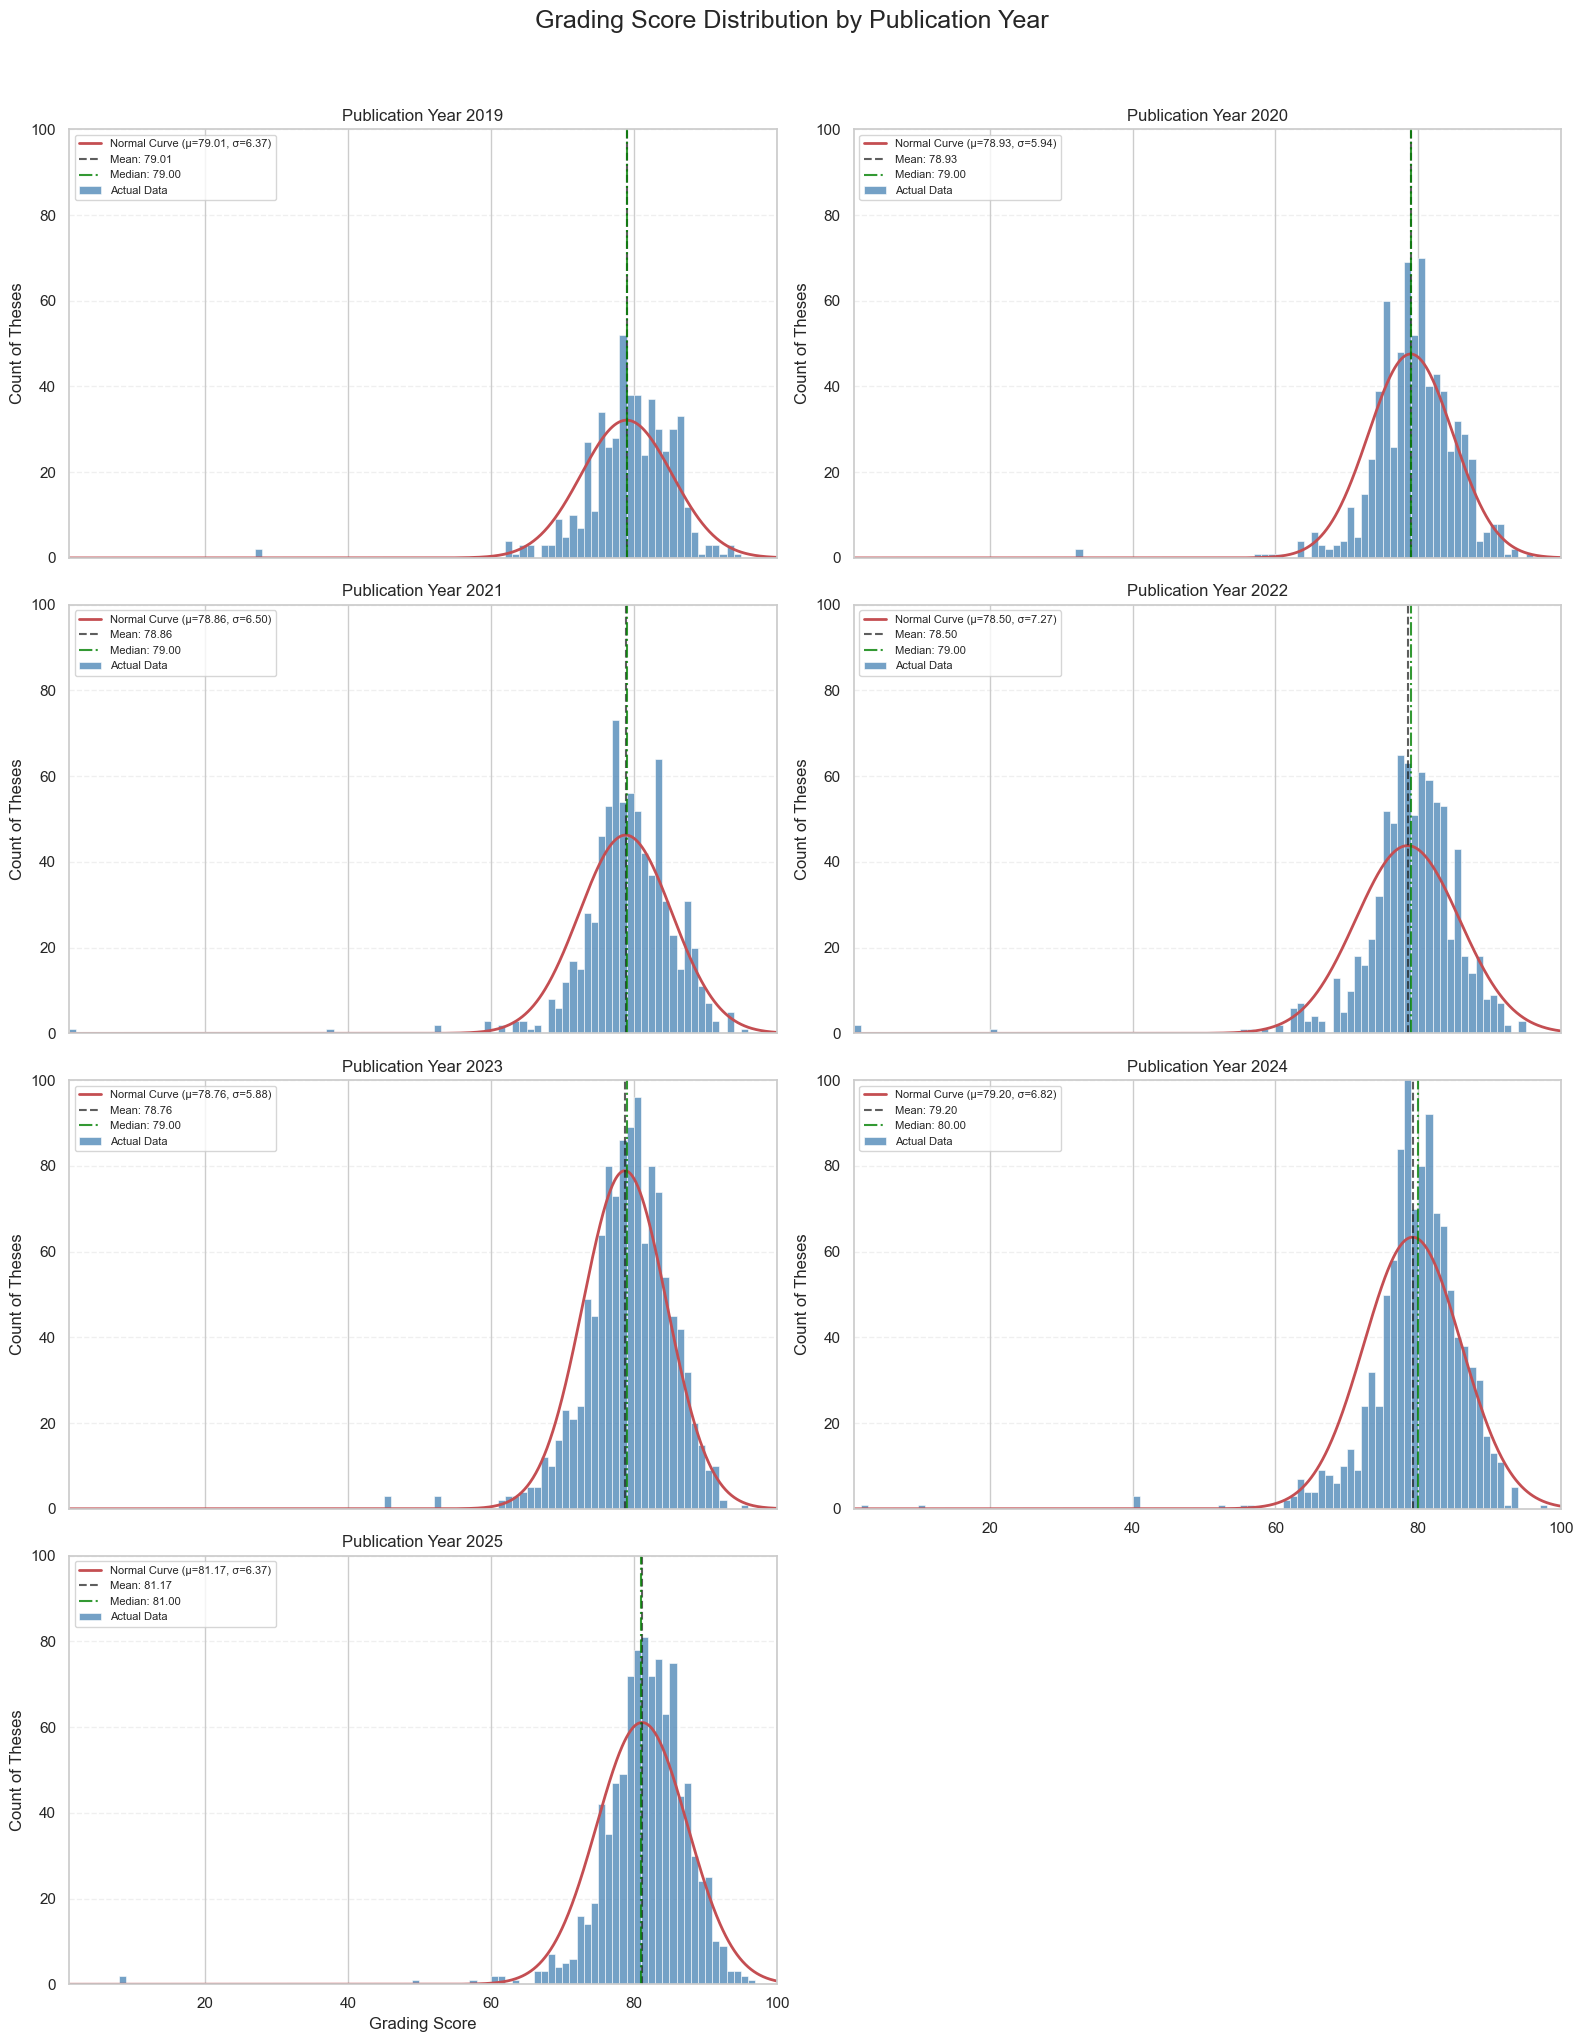

In [25]:
# Grade distribution by year with a normal-curve overlay for visual inspection of skewness and potential grade inflation.
yearly_df = df_filtered_final_noNA_subgrades.copy()
yearly_df['Publication Year'] = pd.to_numeric(yearly_df['Publication Year'], errors='coerce')
yearly_df = yearly_df.dropna(subset=['Publication Year', 'grading_total_score'])

years = sorted(yearly_df['Publication Year'].dropna().astype(int).unique())
cols = 2
rows = int(np.ceil(len(years) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(16, 5 * rows), sharex=True, sharey=False)
axes = np.array(axes).reshape(-1)

show_count = False

for idx, (ax, year) in enumerate(zip(axes, years)):
    year_scores = pd.to_numeric(
        yearly_df.loc[yearly_df['Publication Year'] == year, 'grading_total_score'],
        errors='coerce'
    ).dropna()

    mu, std = year_scores.mean(), year_scores.std()
    median_score = year_scores.median()
    bin_range = np.arange(1, 102)
    sns.histplot(year_scores, bins=bin_range, color='steelblue', kde=False, ax=ax, label='Actual Data')

    x = np.linspace(1, 100, 1000)
    if len(year_scores) > 0 and pd.notna(std) and std > 0:
        p = norm.pdf(x, mu, std) * len(year_scores) * 1
        ax.plot(x, p, 'r', linewidth=2, label=f'Normal Curve (μ={mu:.2f}, σ={std:.2f})')
        ax.axvline(mu, color='k', linestyle='--', alpha=0.7, label=f'Mean: {mu:.2f}')
        ax.axvline(median_score, color='green', linestyle='-.', alpha=0.8, label=f'Median: {median_score:.2f}')
    else:
        ax.axvline(mu, color='k', linestyle='--', alpha=0.7, label=f'Mean: {mu:.2f}')
        ax.axvline(median_score, color='green', linestyle='-.', alpha=0.8, label=f'Median: {median_score:.2f}')

    if show_count:
        for container in ax.containers:
            ax.bar_label(container, fmt='%d', padding=2, fontsize=8)

    ax.set_xlim(1, 100)
    ax.set_ylim(0, 100)
    ax.set_yticks(np.arange(0, 101, 20))
    ax.set_title(f'Publication Year {year}')
    ax.set_ylabel('Count of Theses')
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    ax.legend(fontsize=8)

    # Only show x-axis labels on the bottom-most visible plot in each column.
    row_idx = idx // cols
    col_idx = idx % cols
    is_bottom_in_column = True
    for later_idx in range(idx + cols, len(years), cols):
        if later_idx % cols == col_idx:
            is_bottom_in_column = False
            break
    if is_bottom_in_column:
        ax.set_xlabel('Grading Score')
        ax.tick_params(axis='x', labelbottom=True)
    else:
        ax.set_xlabel('')
        ax.tick_params(axis='x', labelbottom=False)

for ax in axes[len(years):]:
    ax.axis('off')

plt.suptitle('Grading Score Distribution by Publication Year', fontsize=18, y=1.02)
plt.tight_layout()
if IMG_EXPORT:
    plt.savefig(IMG_EXPORT_PATH + 'grading_score_distribution_by_year.png', bbox_inches='tight')
plt.show()

### sub-grades

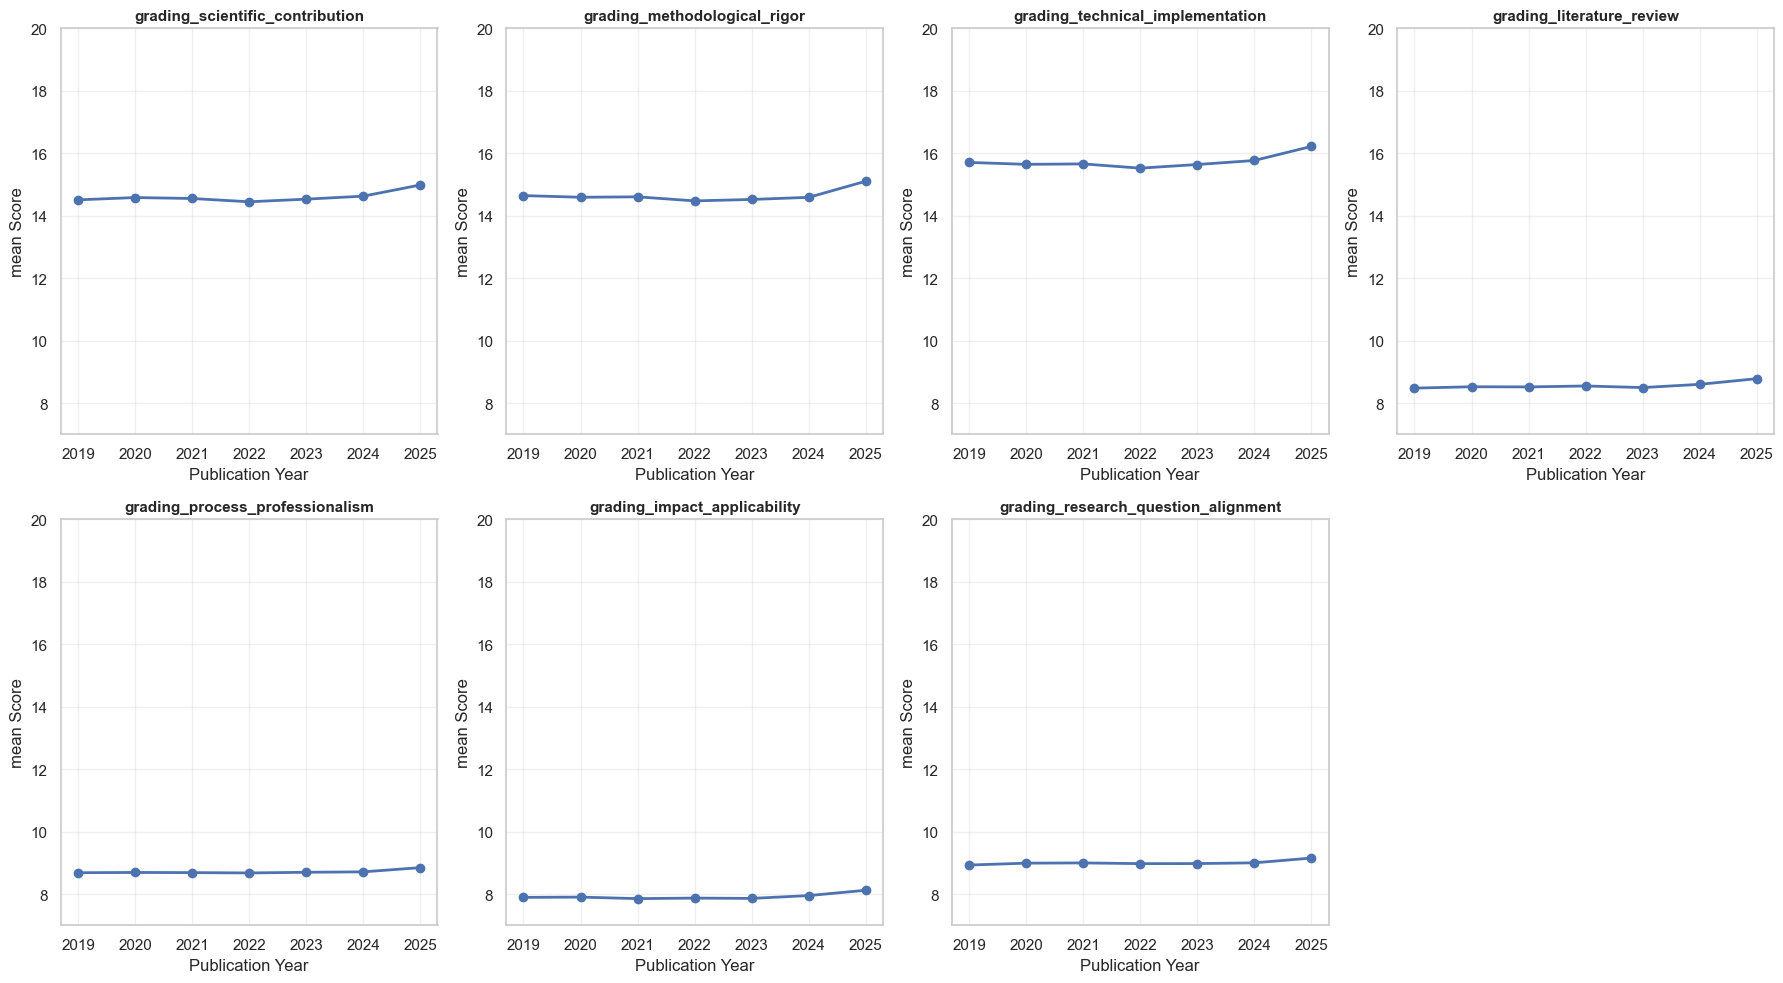

In [13]:
# ==========================================
# PLOT 5: Sub-Grading Trends Over Time
# ==========================================
# Prepare data for all sub-grades
trend_data = []
for grade in sub_grades:
    temp_df = df.groupby('Publication Year')[grade].mean().reset_index()
    temp_df['metric'] = grade
    temp_df.rename(columns={grade: 'mean_score'}, inplace=True)
    trend_data.append(temp_df)

combined_trend_df = pd.concat(trend_data, ignore_index=True)

# Create subplot grid (7 subgrades)
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for idx, grade in enumerate(sub_grades):
    data = combined_trend_df[combined_trend_df['metric'] == grade]
    axes[idx].plot(data['Publication Year'], data['mean_score'], marker='o', linewidth=2, markersize=6)
    axes[idx].set_title(f'{grade}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Publication Year')
    axes[idx].set_ylabel('mean Score')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_ylim(7, 20)

# Hide the last empty subplot
axes[-1].axis('off')

plt.tight_layout()
if IMG_EXPORT:
    plt.savefig(IMG_EXPORT_PATH + 'subgrades_time_trends.png')
plt.show()

### Gradings related to supervisor

In [14]:
# ==========================================
# CONFIGURATION
# ==========================================
MIN_THESES_FOR_SUPERVISOR = 10  # Minimum graded theses a supervisor needs to be included in the chart
NUM_SUPERVISORS_TO_SHOW = 10  # Number of top supervisors to display based on median score 

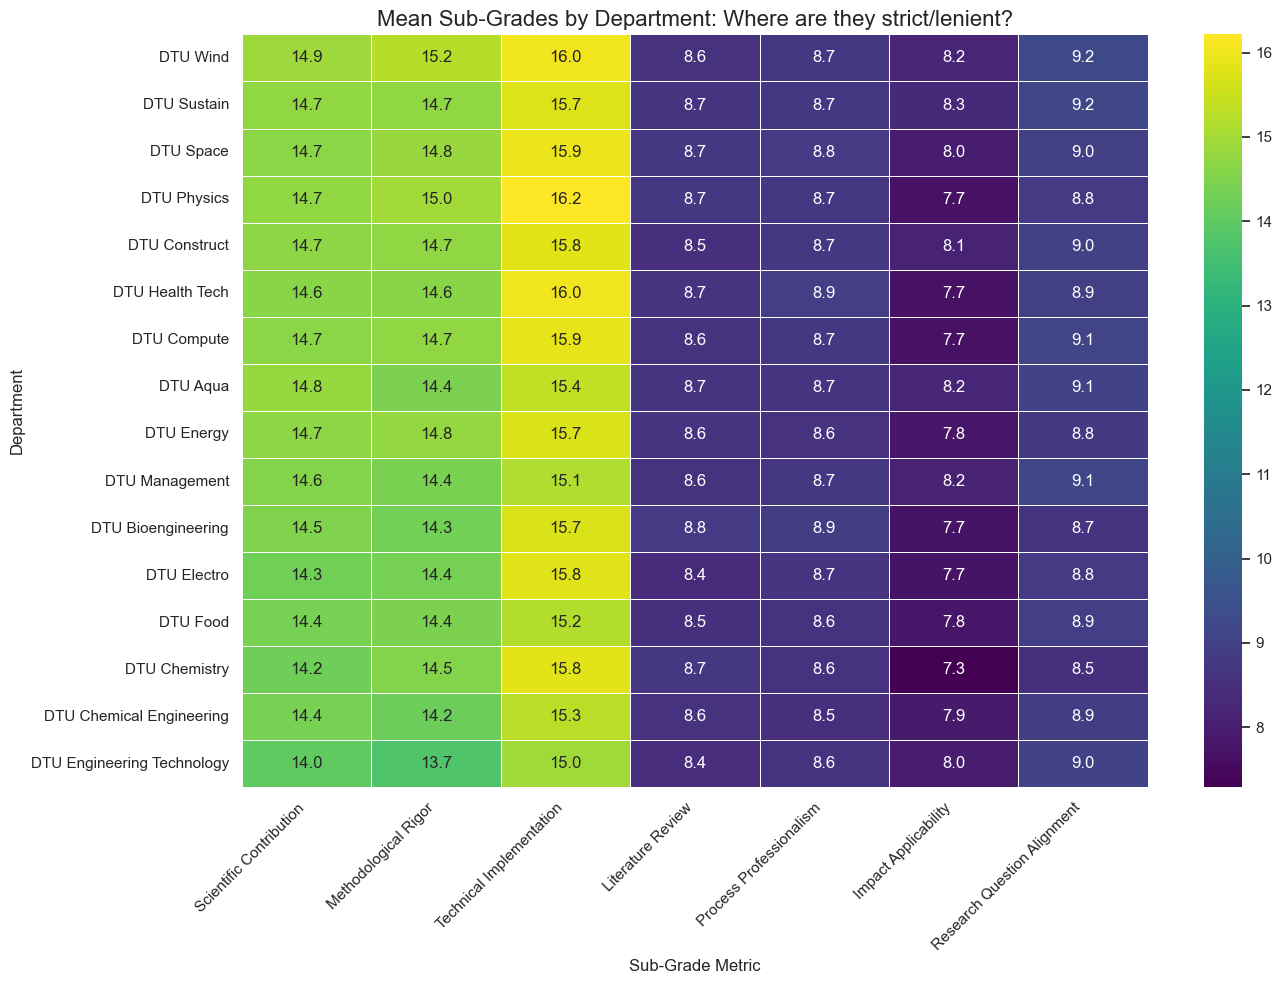

/var/folders/kb/z559lc5s7jzbc1c4j024j2w40000gn/T/ipykernel_80982/3326052792.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=df, x='Department_new', y='grading_total_score', order=order, palette='crest')


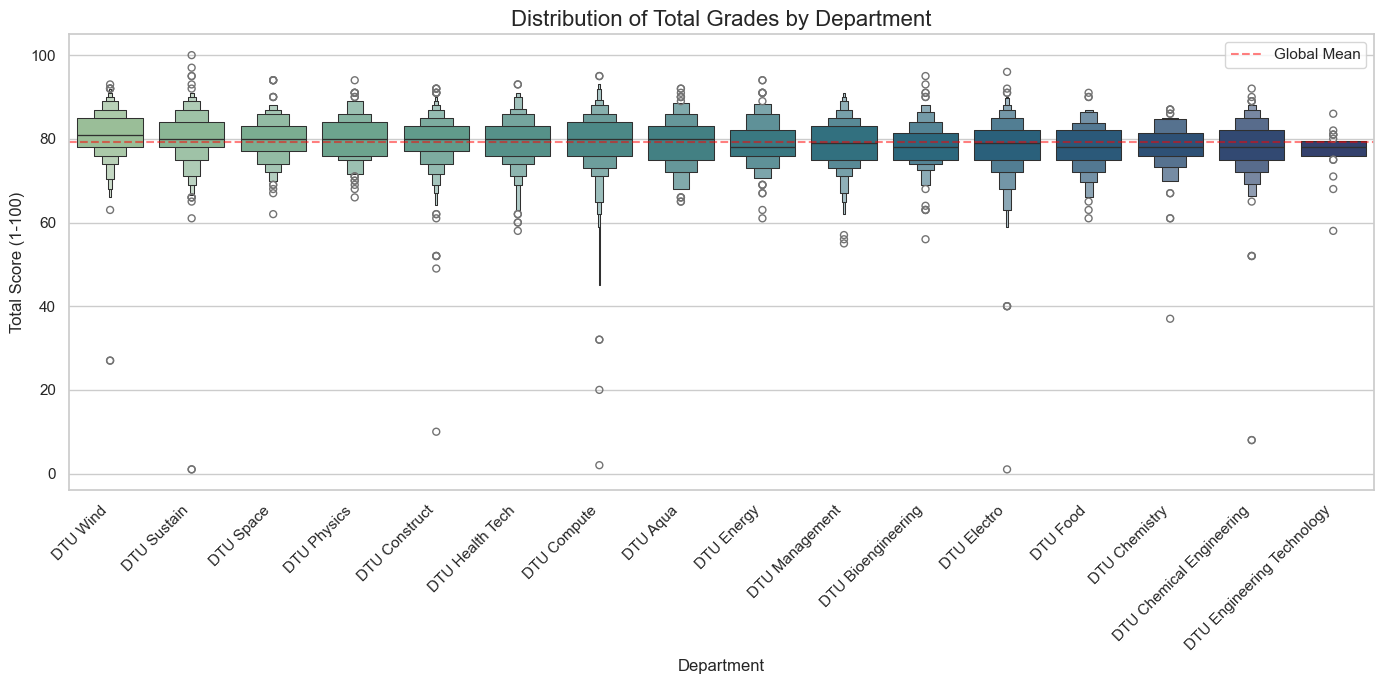

In [15]:
# ==========================================
# PLOT 1: Department Sub-Grade Heatmap
# ==========================================
plt.figure(figsize=(14, 10))

# Calculate the mean score for each sub-grade within each department
dept_subgrades = df.groupby('Department_new')[sub_grades].mean()

# To make the heatmap readable, let's clean up the column names
clean_cols = [col.replace('grading_', '').replace('_', ' ').title() for col in sub_grades]
dept_subgrades.columns = clean_cols

# Sort by the mean of all subgrades so the highest-scoring departments are at the top
dept_subgrades['Mean'] = dept_subgrades.mean(axis=1)
dept_subgrades = dept_subgrades.sort_values('Mean', ascending=False).drop(columns=['Mean'])

sns.heatmap(dept_subgrades, annot=True, cmap='viridis', fmt=".1f", linewidths=.5)
plt.title('Mean Sub-Grades by Department: Where are they strict/lenient?', fontsize=16)
plt.ylabel('Department')
plt.xlabel('Sub-Grade Metric')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
if IMG_EXPORT:
    plt.savefig(IMG_EXPORT_PATH + 'dept_subgrade_heatmap.png')
plt.show()

# ==========================================
# PLOT 2: Department Total Score Distribution
# ==========================================
plt.figure(figsize=(14, 7))

# Get the order of departments by mean total score
order = df.groupby('Department_new')['grading_total_score'].mean().sort_values(ascending=False).index

# A Boxenplot shows the distribution shape better than a standard boxplot
sns.boxenplot(data=df, x='Department_new', y='grading_total_score', order=order, palette='crest')
plt.title('Distribution of Total Grades by Department', fontsize=16)
plt.ylabel('Total Score (1-100)')
plt.xlabel('Department')
plt.xticks(rotation=45, ha='right')
plt.axhline(df['grading_total_score'].mean(), color='red', linestyle='--', alpha=0.5, label='Global Mean')
plt.legend()
plt.tight_layout()
if IMG_EXPORT:
    plt.savefig(IMG_EXPORT_PATH + 'dept_total_grade_distribution.png')
plt.show()

## Temporal Analysis (trends in hand-in month)

/var/folders/kb/z559lc5s7jzbc1c4j024j2w40000gn/T/ipykernel_80982/2353364874.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='clean_month_str', palette='crest')


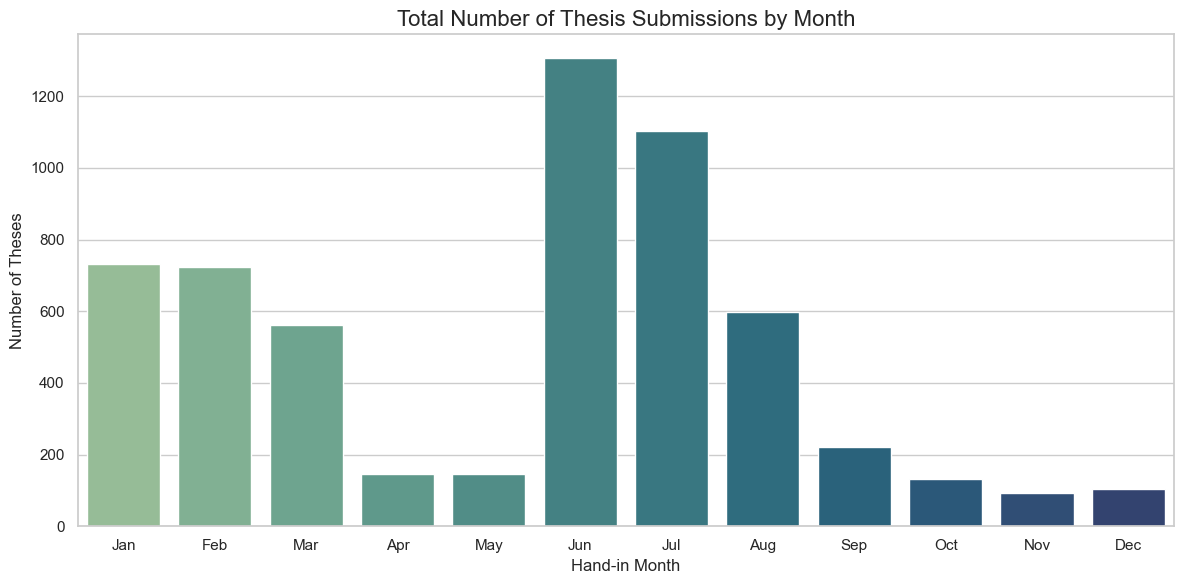

/var/folders/kb/z559lc5s7jzbc1c4j024j2w40000gn/T/ipykernel_80982/2353364874.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='clean_month_str', y=target, palette='viridis')


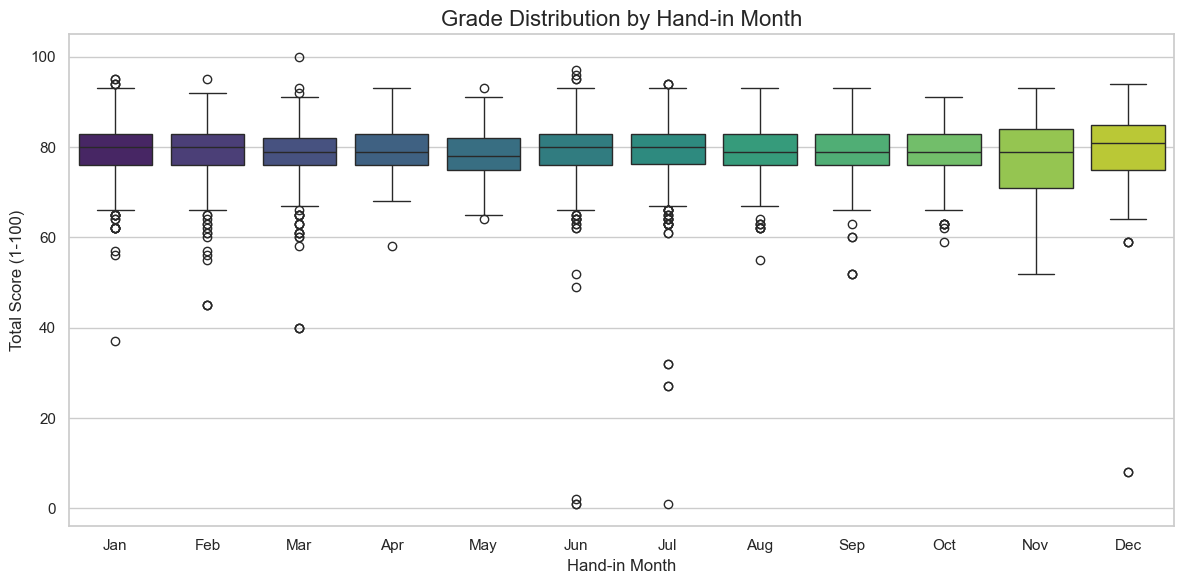

In [16]:
# 1. Load the dataset
target = 'grading_total_score'

# 2. Clean the handin_month column
# This function extracts the month name, ignoring numbers (years) and standardizing the format.
def extract_month(text):
    if pd.isna(text):
        return None
    # Remove numbers and strip whitespace
    clean_text = re.sub(r'\d+', '', str(text)).strip().title()
    # Take the first 3 letters to standardize (e.g., "January", "Jan", "Jan.") -> "Jan"
    return clean_text[:3] if len(clean_text) >= 3 else None

df['clean_month_str'] = df['handin_month'].apply(extract_month)

# Create a mapping to ensure months are plotted in chronological order, not alphabetical
month_abbr = [calendar.month_abbr[i] for i in range(1, 13)] # ['Jan', 'Feb', 'Mar', ...]
df['clean_month_str'] = pd.Categorical(df['clean_month_str'], categories=month_abbr, ordered=True)

# Set the visual style
sns.set_theme(style="whitegrid")

# ==========================================
# PLOT 1: Volume of Theses by Month
# ==========================================
# Question: Are there massive spikes in hand-ins (e.g., June/July)?
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='clean_month_str', palette='crest')
plt.title('Total Number of Thesis Submissions by Month', fontsize=16)
plt.xlabel('Hand-in Month')
plt.ylabel('Number of Theses')
plt.tight_layout()
if IMG_EXPORT:
    plt.savefig(IMG_EXPORT_PATH + 'submissions_by_month.png')
plt.show()

# ==========================================
# PLOT 2: Grade Distribution by Month
# ==========================================
# Question: Does handing in during a "rush" month lower the average grade?
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='clean_month_str', y=target, palette='viridis')
plt.title('Grade Distribution by Hand-in Month', fontsize=16)
plt.xlabel('Hand-in Month')
plt.ylabel('Total Score (1-100)')
plt.tight_layout()
if IMG_EXPORT:
    plt.savefig(IMG_EXPORT_PATH + 'grades_by_month.png')
plt.show()

Unique supervisors after splitting: 2340
Supervisors with at least 10 theses: 300
Showing top 10 and bottom 10 supervisors by median grade.


/var/folders/kb/z559lc5s7jzbc1c4j024j2w40000gn/T/ipykernel_80982/3244672294.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/kb/z559lc5s7jzbc1c4j024j2w40000gn/T/ipykernel_80982/3244672294.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


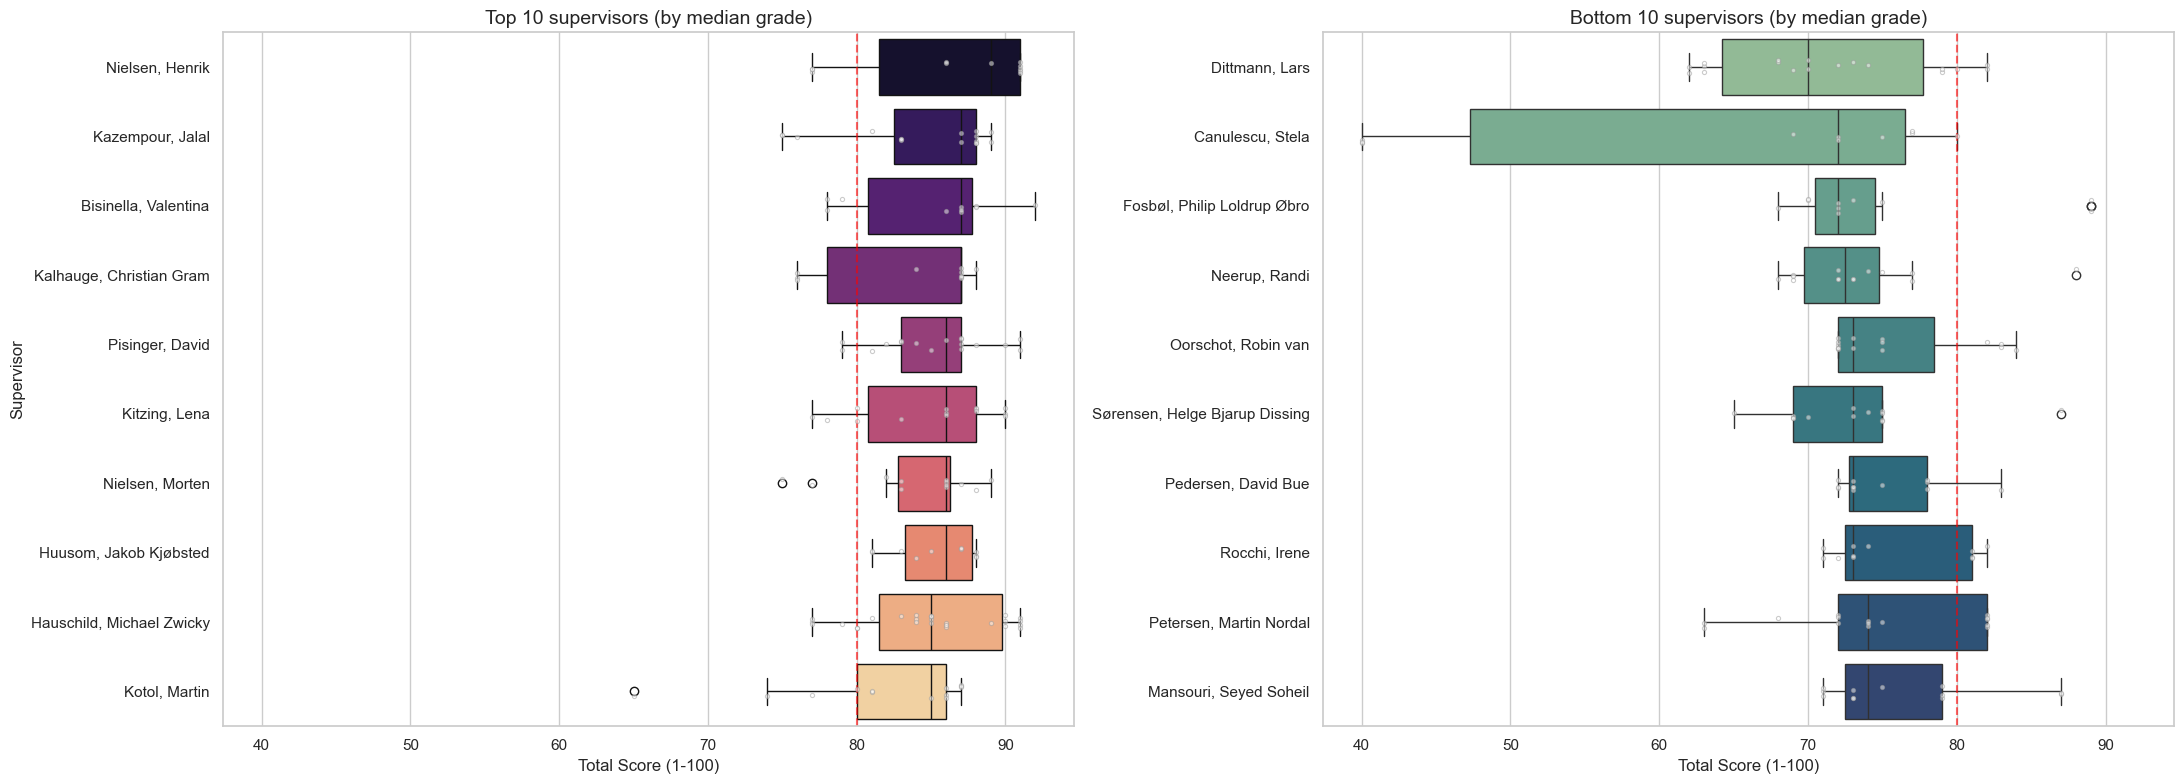

In [17]:
# ==========================================
# PLOT 3: Supervisor Impact (Top vs Bottom side-by-side)
# ==========================================
# Split multi-supervisor entries so each thesis counts for every listed supervisor.
supervisor_df = df[['SUPERVISED BY', 'grading_total_score']].dropna(subset=['SUPERVISED BY', 'grading_total_score']).copy()
supervisor_df['SUPERVISED BY'] = supervisor_df['SUPERVISED BY'].astype(str).str.split(';')
supervisor_df = supervisor_df.explode('SUPERVISED BY')
supervisor_df['SUPERVISED BY'] = supervisor_df['SUPERVISED BY'].astype(str).str.strip()
supervisor_df = supervisor_df[supervisor_df['SUPERVISED BY'] != '']

# Summarize by supervisor after splitting multi-supervisor theses.
supervisor_summary = (
    supervisor_df.groupby('SUPERVISED BY')['grading_total_score']
    .agg(thesis_count='size', median_score='median')
)

# Keep only supervisors meeting minimum sample size
valid_supervisors = supervisor_summary[supervisor_summary['thesis_count'] >= MIN_THESES_FOR_SUPERVISOR]

# Rank by grade (median_score), tie-break by thesis_count
top_ranked = valid_supervisors.sort_values(['median_score', 'thesis_count'], ascending=[False, False])
plot_limit = min(NUM_SUPERVISORS_TO_SHOW, len(top_ranked))

plot_top_supervisors = top_ranked.head(plot_limit).copy()

# Avoid overlap if dataset is small
remaining = valid_supervisors.drop(index=plot_top_supervisors.index, errors='ignore')
bottom_ranked = remaining.sort_values(['median_score', 'thesis_count'], ascending=[True, False])
bottom_limit = min(NUM_SUPERVISORS_TO_SHOW, len(bottom_ranked))
plot_bottom_supervisors = bottom_ranked.head(bottom_limit).copy()

top_supervisors_df = supervisor_df[supervisor_df['SUPERVISED BY'].isin(plot_top_supervisors.index)].copy()
bottom_supervisors_df = supervisor_df[supervisor_df['SUPERVISED BY'].isin(plot_bottom_supervisors.index)].copy()

print(f"Unique supervisors after splitting: {len(supervisor_summary)}")
print(f"Supervisors with at least {MIN_THESES_FOR_SUPERVISOR} theses: {len(valid_supervisors)}")
print(f"Showing top {len(plot_top_supervisors)} and bottom {len(plot_bottom_supervisors)} supervisors by median grade.")

fig_height = max(8, 0.35 * max(len(plot_top_supervisors), len(plot_bottom_supervisors)))
fig, axes = plt.subplots(1, 2, figsize=(22, fig_height), sharex=True)

top_order = plot_top_supervisors['median_score'].sort_values(ascending=False).index
bottom_order = plot_bottom_supervisors['median_score'].sort_values(ascending=True).index

# Top supervisors panel
sns.boxplot(
    data=top_supervisors_df, y='SUPERVISED BY', x='grading_total_score',
    order=top_order, palette='magma', ax=axes[0]
)
sns.stripplot(
    data=top_supervisors_df, y='SUPERVISED BY', x='grading_total_score',
    order=top_order, color='white', alpha=0.5, size=3, linewidth=0.8, ax=axes[0]
)
axes[0].set_title(f'Top {len(plot_top_supervisors)} supervisors (by median grade)', fontsize=14)
axes[0].set_xlabel('Total Score (1-100)')
axes[0].set_ylabel('Supervisor')
axes[0].axvline(df['grading_total_score'].median(), color='red', linestyle='--', alpha=0.6)

# Bottom supervisors panel
sns.boxplot(
    data=bottom_supervisors_df, y='SUPERVISED BY', x='grading_total_score',
    order=bottom_order, palette='crest', ax=axes[1]
)
sns.stripplot(
    data=bottom_supervisors_df, y='SUPERVISED BY', x='grading_total_score',
    order=bottom_order, color='white', alpha=0.5, size=3, linewidth=0.8, ax=axes[1]
)
axes[1].set_title(f'Bottom {len(plot_bottom_supervisors)} supervisors (by median grade)', fontsize=14)
axes[1].set_xlabel('Total Score (1-100)')
axes[1].set_ylabel('')
axes[1].axvline(df['grading_total_score'].median(), color='red', linestyle='--', alpha=0.6)

plt.tight_layout()
if IMG_EXPORT:
    plt.savefig(IMG_EXPORT_PATH + 'supervisor_impact_top_bottom_side_by_side.png')
plt.show()

Showing top 11 and bottom 10 supervisors by median grade.


/var/folders/kb/z559lc5s7jzbc1c4j024j2w40000gn/T/ipykernel_80982/482345128.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/kb/z559lc5s7jzbc1c4j024j2w40000gn/T/ipykernel_80982/482345128.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


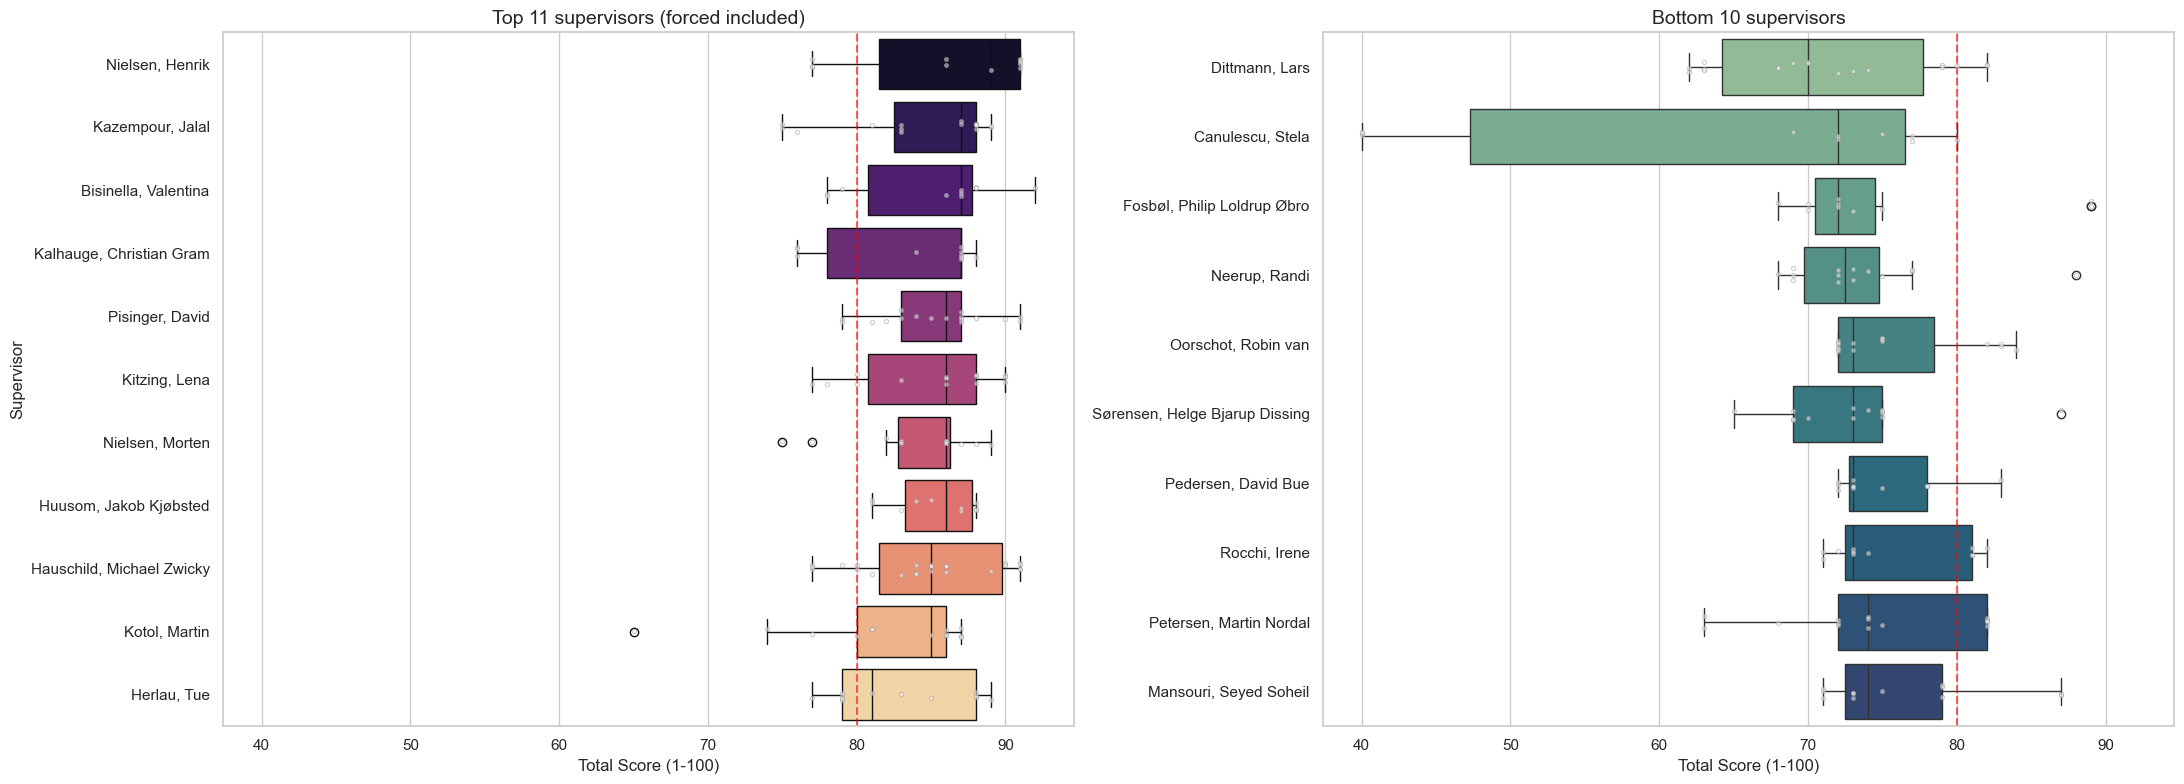

In [18]:
# Keep only supervisors meeting minimum sample size
valid_supervisors = supervisor_summary[supervisor_summary['thesis_count'] >= MIN_THESES_FOR_SUPERVISOR]

# Hardcode supervisors you always want shown (case-insensitive)
FORCE_SUPERVISORS = ["Herlau, Tue"]

# Build a case-insensitive lookup from the actual supervisor names in your data
name_lookup = {name.strip().lower(): name for name in supervisor_summary.index}
forced_found = []
forced_missing = []

for raw_name in FORCE_SUPERVISORS:
    key = raw_name.strip().lower()
    if key in name_lookup:
        forced_found.append(name_lookup[key])
    else:
        forced_missing.append(raw_name)

# Rank by grade (median_score), tie-break by thesis_count
top_ranked = valid_supervisors.sort_values(["median_score", "thesis_count"], ascending=[False, False])
plot_limit = min(NUM_SUPERVISORS_TO_SHOW, len(top_ranked))

# Start with normal top list
selected_top = list(top_ranked.head(plot_limit).index)

# Add forced supervisors even if they are below threshold
for sup in forced_found:
    if sup not in selected_top:
        selected_top.append(sup)

plot_top_supervisors = supervisor_summary.loc[selected_top].copy()

# Bottom list still from threshold-based set, excluding anything already in top panel
remaining = valid_supervisors.drop(index=plot_top_supervisors.index, errors="ignore")
bottom_ranked = remaining.sort_values(["median_score", "thesis_count"], ascending=[True, False])
bottom_limit = min(NUM_SUPERVISORS_TO_SHOW, len(bottom_ranked))
plot_bottom_supervisors = bottom_ranked.head(bottom_limit).copy()

top_supervisors_df = supervisor_df[supervisor_df["SUPERVISED BY"].isin(plot_top_supervisors.index)].copy()
bottom_supervisors_df = supervisor_df[supervisor_df["SUPERVISED BY"].isin(plot_bottom_supervisors.index)].copy()

if forced_missing:
    print(f"Forced supervisor(s) not found: {forced_missing}")

print(f"Showing top {len(plot_top_supervisors)} and bottom {len(plot_bottom_supervisors)} supervisors by median grade.")

fig_height = max(8, 0.35 * max(len(plot_top_supervisors), len(plot_bottom_supervisors)))
fig, axes = plt.subplots(1, 2, figsize=(22, fig_height), sharex=True)

top_order = plot_top_supervisors['median_score'].sort_values(ascending=False).index
bottom_order = plot_bottom_supervisors['median_score'].sort_values(ascending=True).index

# Top supervisors panel
sns.boxplot(
    data=top_supervisors_df, y='SUPERVISED BY', x='grading_total_score',
    order=top_order, palette='magma', ax=axes[0]
)
sns.stripplot(
    data=top_supervisors_df, y='SUPERVISED BY', x='grading_total_score',
    order=top_order, color='white', alpha=0.5, size=3, linewidth=0.8, ax=axes[0]
)
axes[0].set_title(f'Top {len(plot_top_supervisors)} supervisors (forced included)', fontsize=14)
axes[0].set_xlabel('Total Score (1-100)')
axes[0].set_ylabel('Supervisor')
axes[0].axvline(df['grading_total_score'].median(), color='red', linestyle='--', alpha=0.6)

# Bottom supervisors panel
sns.boxplot(
    data=bottom_supervisors_df, y='SUPERVISED BY', x='grading_total_score',
    order=bottom_order, palette='crest', ax=axes[1]
)
sns.stripplot(
    data=bottom_supervisors_df, y='SUPERVISED BY', x='grading_total_score',
    order=bottom_order, color='white', alpha=0.5, size=3, linewidth=0.8, ax=axes[1]
)
axes[1].set_title(f'Bottom {len(plot_bottom_supervisors)} supervisors', fontsize=14)
axes[1].set_xlabel('Total Score (1-100)')
axes[1].set_ylabel('')
axes[1].axvline(df['grading_total_score'].median(), color='red', linestyle='--', alpha=0.6)

plt.tight_layout()
if IMG_EXPORT:
    plt.savefig(IMG_EXPORT_PATH + 'supervisor_impact_top_bottom_forced.png')
plt.show()

# ARCHIVES

## Legacy prints

In [19]:
#show 10% lowest total scores, show collumns: "title", "Department_new", "Publication Year", "grading_total_score"
df_filtered_final_noNA.nsmallest(int(0.1 * len(df_filtered_final_noNA)), "grading_total_score")[["pdf_file", "Department_new", "Publication Year", "grading_total_score"]]

,pdf_file,Department_new,Publication Year,grading_total_score
1199,612e0e46d9001d0172372029_Autonomous indoor exp...,DTU Electro,2021,1.0
2236,62d0b03e695d6726170247b6_Evaluating the qualit...,DTU Sustain,2022,1.0
2933,62d0b03e695d6726170247b6_Evaluating the qualit...,DTU Sustain,2022,1.0
1193,669468d1cfd87be8f3dfe478_Ø-modeller til estima...,DTU Compute,2024,2.0
2872,64f12babfdcf8022a630b09a_Fuzzing Smart Contrac...,DTU Compute,2023,8.0
...,...,...,...,...
724,65024f36a063b61200008a4b_Detection of waste di...,DTU Management,2023,73.0
735,5f46437dd9001d01721d7dee_Using frame creation ...,DTU Management,2020,73.0
812,641ba6cff48e263c29c3d448_Analysing performance...,DTU Construct,2023,73.0
814,63056c533a2731132550daff_Conjugation of M-cell...,DTU Health Tech,2022,73.0


## Legacy: Sub-plots grading over time single plots

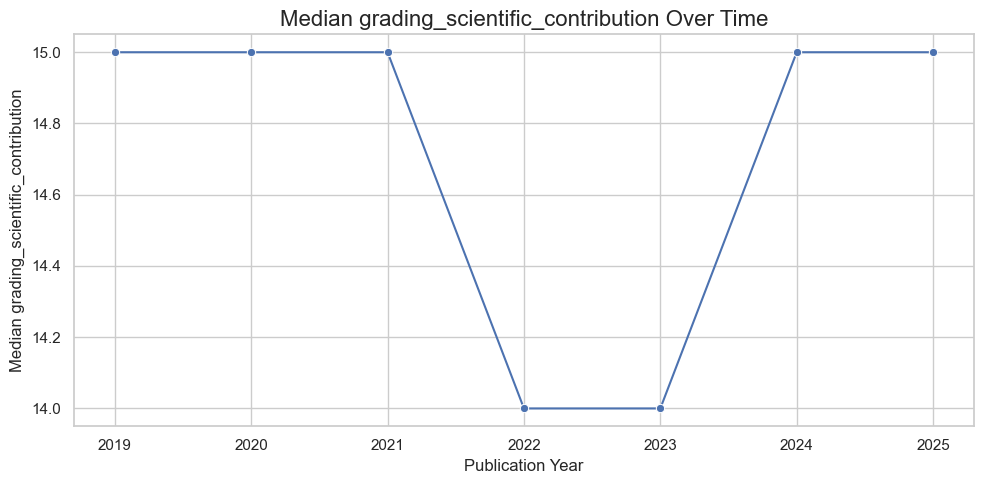

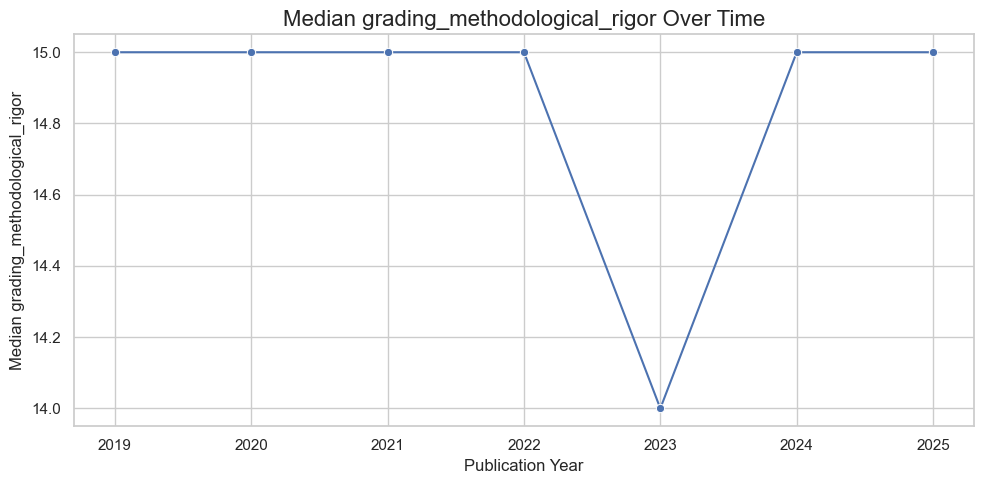

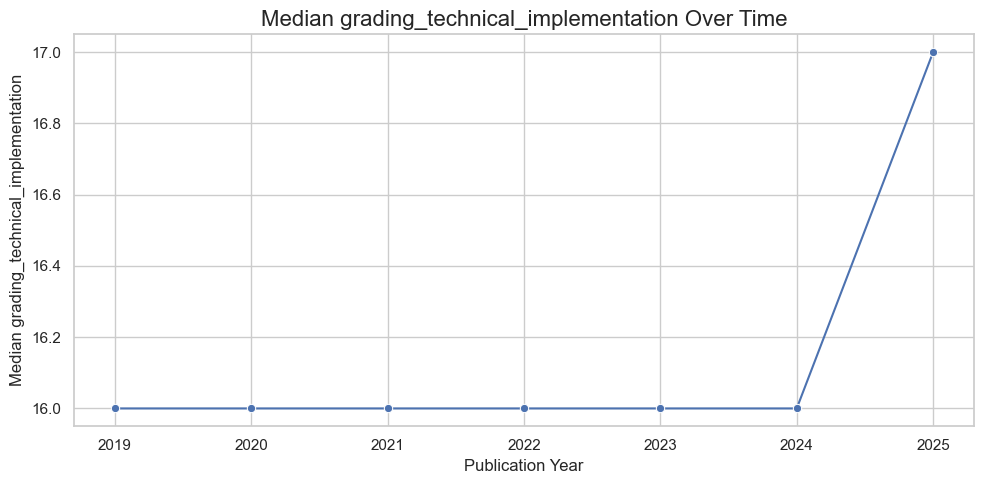

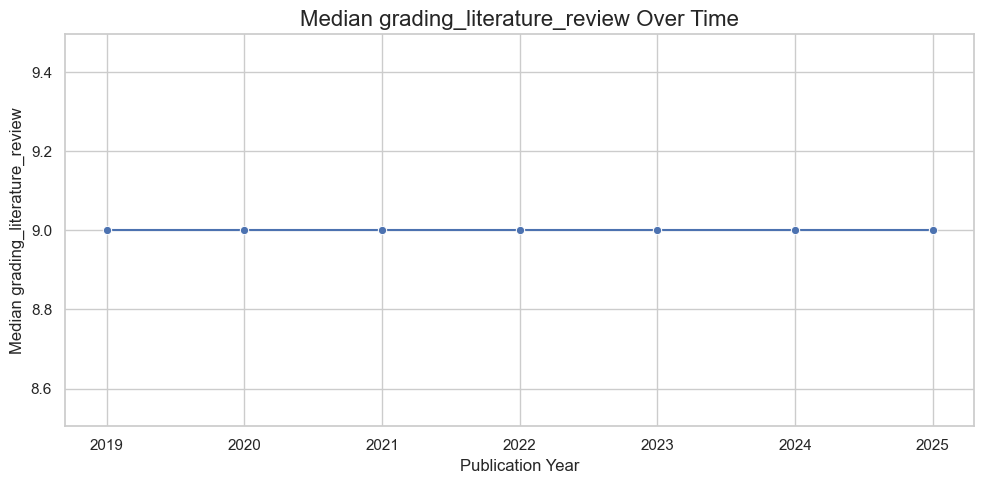

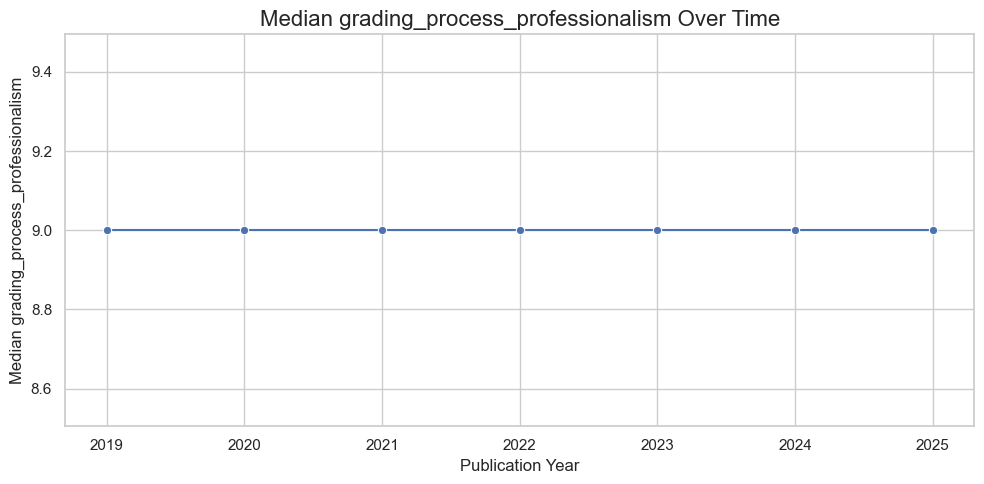

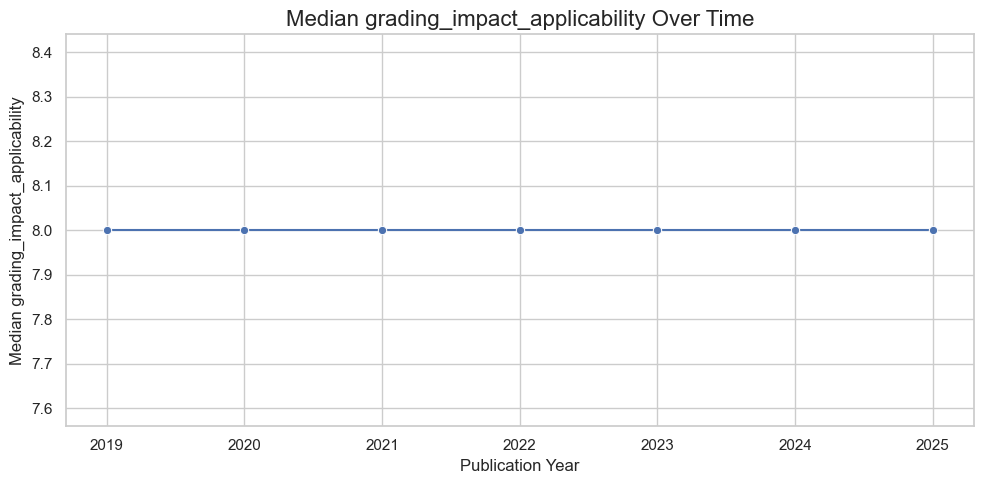

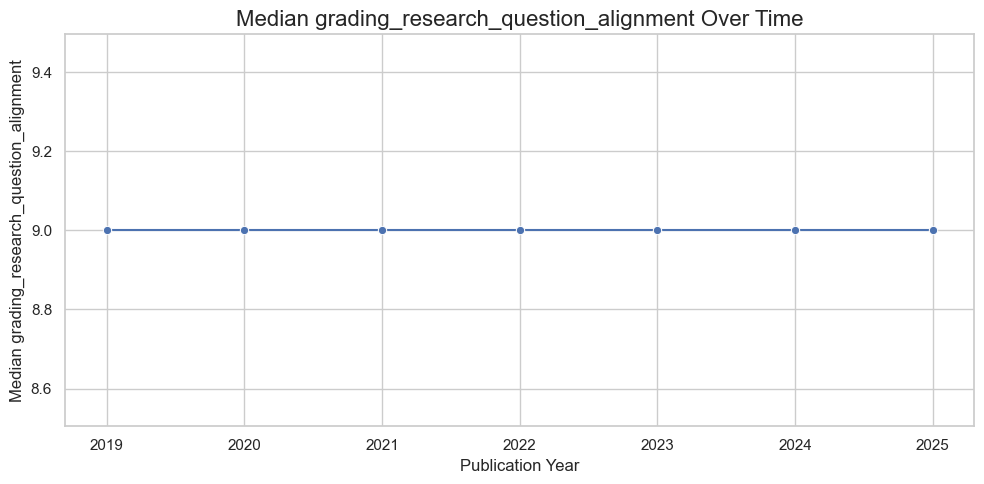

In [20]:
# ==========================================
# PLOT 5: Sub-Grading Trends Over Time
# ==========================================

for i in sub_grades:
    plt.figure(figsize=(10, 5))
    #sns.lineplot(data=df, x='Publication Year', y=i, marker='o', errorbar=None)
    sns.lineplot(data=df.groupby('Publication Year')[i].median().reset_index(), x='Publication Year', y=i, marker='o')
    plt.title(f'Median {i} Over Time', fontsize=16)
    plt.ylabel(f'Median {i}')
    plt.xticks(df['Publication Year'].dropna().unique()) # Ensure whole years
    plt.tight_layout()
    plt.show()

## Finding a supervisor by name

In [21]:
supervisor_name = "herlau, tue"

# find supervisor_name in valid_supervisors (case-insensitive exact match)
supervisor_key = supervisor_name.strip().lower()

match = valid_supervisors[
    valid_supervisors.index.to_series().str.strip().str.lower() == supervisor_key
]

if match.empty:
    print(f'"{supervisor_name}" was not found in valid_supervisors.')
else:
    print(f'Found "{supervisor_name}" in valid_supervisors:')
    print(match)
    print()

# checking the data for the supervisor "herlau, tue"
herlau_theses = supervisor_df[supervisor_df['SUPERVISED BY'].str.lower() == supervisor_name.lower()]
print(f"Theses supervised by {supervisor_name}:\n{herlau_theses}")



Found "herlau, tue" in valid_supervisors:
               thesis_count  median_score
SUPERVISED BY                            
Herlau, Tue              13          81.0

Theses supervised by herlau, tue:
     SUPERVISED BY  grading_total_score
363    Herlau, Tue                 88.0
447    Herlau, Tue                 89.0
718    Herlau, Tue                 83.0
823    Herlau, Tue                 79.0
950    Herlau, Tue                 79.0
1074   Herlau, Tue                 79.0
1308   Herlau, Tue                 85.0
1439   Herlau, Tue                 81.0
1850   Herlau, Tue                 77.0
2670   Herlau, Tue                 88.0
3796   Herlau, Tue                 88.0
5660   Herlau, Tue                 79.0
5802   Herlau, Tue                 79.0


## Supervisor Impact single plot

Unique supervisors after splitting: 2340
Supervisors with at least 10 theses: 300
To access the full summary of supervisors (thesis count and median score), use: supervisor_summary
To access the full list of supervisors meeting the threshold, use: valid_supervisors
Plotting the top 10 supervisors by thesis count for readability.


/var/folders/kb/z559lc5s7jzbc1c4j024j2w40000gn/T/ipykernel_80982/953194074.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


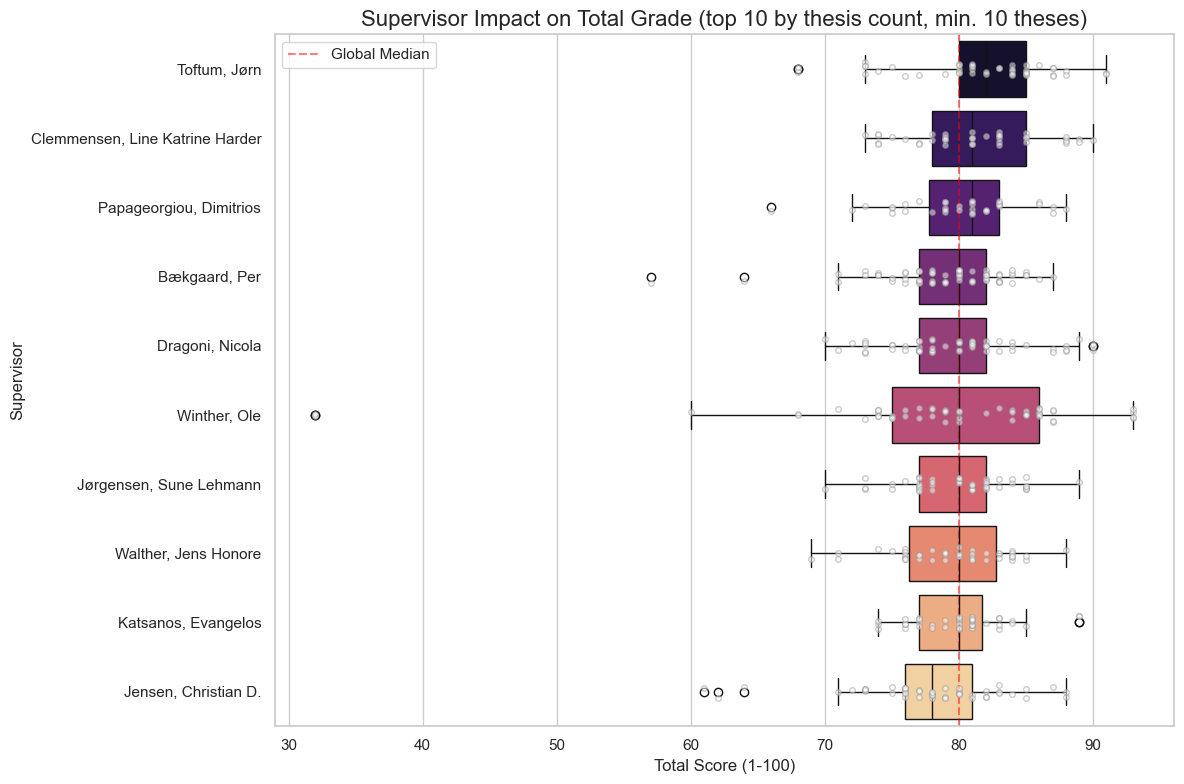

In [22]:
# ==========================================
# PLOT 3: Supervisor Impact
# ==========================================
# Split multi-supervisor entries so each thesis counts for every listed supervisor.
supervisor_df = df[['SUPERVISED BY', 'grading_total_score']].dropna(subset=['SUPERVISED BY', 'grading_total_score']).copy()
supervisor_df['SUPERVISED BY'] = supervisor_df['SUPERVISED BY'].astype(str).str.split(';')
supervisor_df = supervisor_df.explode('SUPERVISED BY')
supervisor_df['SUPERVISED BY'] = supervisor_df['SUPERVISED BY'].astype(str).str.strip()
supervisor_df = supervisor_df[supervisor_df['SUPERVISED BY'] != '']

# Summarize by supervisor after splitting multi-supervisor theses.
supervisor_summary = (
    supervisor_df.groupby('SUPERVISED BY')['grading_total_score']
    .agg(thesis_count='size', median_score='median')
    .sort_values(['thesis_count', 'median_score'], ascending=[False, False])
)

# Keep only those who meet the minimum threshold, then show the most represented supervisors.
valid_supervisors = supervisor_summary[supervisor_summary['thesis_count'] >= MIN_THESES_FOR_SUPERVISOR]
plot_limit = NUM_SUPERVISORS_TO_SHOW if len(valid_supervisors) > NUM_SUPERVISORS_TO_SHOW else len(valid_supervisors)
plot_supervisors = valid_supervisors.head(plot_limit).copy()
top_supervisors_df = supervisor_df[supervisor_df['SUPERVISED BY'].isin(plot_supervisors.index)].copy()

print(f"Unique supervisors after splitting: {len(supervisor_summary)}")
print(f"Supervisors with at least {MIN_THESES_FOR_SUPERVISOR} theses: {len(valid_supervisors)}")
print(f"To access the full summary of supervisors (thesis count and median score), use: supervisor_summary")
print(f"To access the full list of supervisors meeting the threshold, use: valid_supervisors")
print(f"Plotting the top {len(plot_supervisors)} supervisors by thesis count for readability.")

plt.figure(figsize=(12, max(8, 0.45 * len(plot_supervisors))))

# Order by median score
sup_order = plot_supervisors['median_score'].sort_values(ascending=False).index

sns.boxplot(
    data=top_supervisors_df, 
    y='SUPERVISED BY', 
    x='grading_total_score', 
    order=sup_order, 
    palette='magma'
)
# Add a strip plot on top to see the actual individual thesis-supervisor assignments
sns.stripplot(
    data=top_supervisors_df, 
    y='SUPERVISED BY', 
    x='grading_total_score', 
    order=sup_order, 
    color='white', 
    alpha=0.5, 
    size=4, 
    linewidth=1
)

plt.title(f'Supervisor Impact on Total Grade (top {plot_limit} by thesis count, min. {MIN_THESES_FOR_SUPERVISOR} theses)', fontsize=16)
plt.xlabel('Total Score (1-100)')
plt.ylabel('Supervisor')
plt.axvline(df['grading_total_score'].median(), color='red', linestyle='--', alpha=0.5, label='Global Median')
plt.legend()
plt.tight_layout()
if IMG_EXPORT:
    plt.savefig(IMG_EXPORT_PATH + 'supervisor_impact.png')
plt.show()

## Plot numb thesis with grades pr. year

/var/folders/kb/z559lc5s7jzbc1c4j024j2w40000gn/T/ipykernel_80982/938035137.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


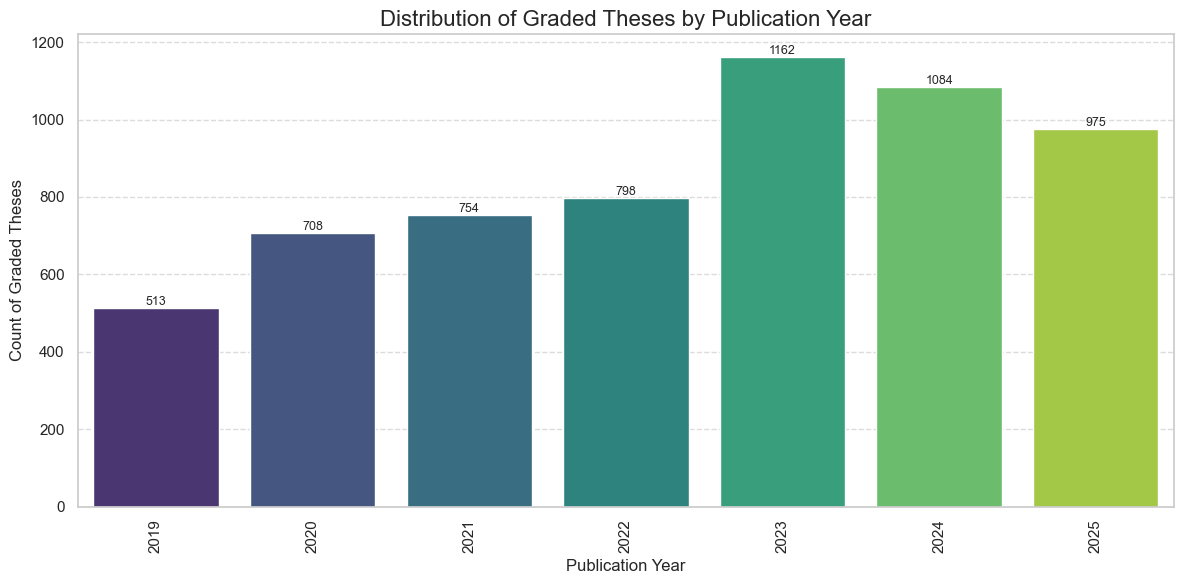

In [23]:
# plotting number of thesis with grades pr. year as a bar plot
plt.figure(figsize=(12, 6))
year_order = sorted(pd.to_numeric(df["Publication Year"], errors="coerce").dropna().unique())
ax = sns.countplot(
    data=df,
    x='Publication Year',
    order=year_order,
    palette='viridis'
)
# add count labels at the end (top) of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=0, fontsize=9)
plt.xticks(rotation=90)
plt.title('Distribution of Graded Theses by Publication Year', fontsize=16)
plt.xlabel('Publication Year')
plt.ylabel('Count of Graded Theses')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
#if IMG_EXPORT:
#    plt.savefig(IMG_EXPORT_PATH + 'graded_theses_by_year.png')
plt.show()

## [new legacy element here]